`[Homework] Предсказание разрушение портала`

**Цель:** Разработать модель машинного обучения для предсказания значения переменной `Гармония Бессмертия`, которая является ключевым показателем стабильности магического портала.

**Тип задачи:** Поскольку целевая переменная (`Гармония Бессмертия`) является непрерывной величиной, задача относится к классу **регрессии**.

`Содержание ноутбука`

**Table of contents**<a id='toc0_'></a>
- 1. [Раздел 1. Обработка входных данных и датасета](#toc1_)
  - 1.1. [Research](#toc1_1_)
    - 1.1.1. [Загрузка исходных данных](#toc1_1_1_)
    - 1.1.2. [Анализ типов данных и значений признаков](#toc1_1_2_)
    - 1.1.3. [Формирование обучающей и тестирующей выборок](#toc1_1_3_)
    - 1.1.4. [Обработка категориальных признаков](#toc1_1_4_)
      - 1.1.4.1. [Кодирование категориальных данных](#toc1_1_4_1_)
    - 1.1.5. [Обработка вещественных признаков](#toc1_1_5_)  
      - 1.1.5.1 [Заполнение пропущенных значений](#toc1_1_5_1_)  
        - 1.1.5.1.1 [Заполнение пропущенных значений статистическим методом](#toc1_1_5_1_1_)
        - 1.1.5.1.2 [Заполнение пропущенных значений машинными подходами](#toc1_1_5_1_2_)
          - 1.1.5.1.2.1 [Заполнение пропущенных значений методом MICE](#toc1_1_5_1_2_1_)
          - 1.1.5.1.2.2 [Заполнение пропущенных значений методом KNNImputer](#toc1_1_5_1_2_2_)
    - 1.1.6 [Устранение проблемы наличия выбросов и аномалий в данных](#toc1_1_6_)
      - 1.1.6.1 [Устранение проблемы наличия выбросов в данных](#toc1_1_6_1_)
        - 1.1.6.1.1 [Квартильный анализ (IQR)](#toc1_1_6_1_1_)
        - 1.1.6.1.2 [Robust Z-score](#toc1_1_6_1_2_)
      - 1.1.6.2 [Устранение проблемы наличия аномалий в данных](#toc1_1_6_2_)
        - 1.1.6.2.1 [Поиск на основе IsolationForest](#toc1_1_6_2_1_)
        - 1.1.6.2.2 [Поиск на основе SVM](#toc1_1_6_2_2_)
        - 1.1.6.2.3 [Поиск на основе DBSCAN](#toc1_1_6_2_3_)
        - 1.1.6.2.4 [Удаление аномальных точек](#toc1_1_6_2_4_)
    - 1.1.7 [Проблема мультиколлинеарности](#toc1_1_7_)

`Структура ноутбука`

Каждый раздел состоит из двух частей:
 - `research (необязательная)` — включает в себя вспомогательные исследования, тесты, визуализации, диаграммы и аналитические выкладки, используемые в процессе работы;
 - `production (обязательная)` — содержит финальный, чистый и воспроизводимый код, который используется для запуска и проверки.

`Формирование окружения для работы`

Первоначально необходимо подготовить окружение для работы с данными и их моделирования. Чтобы не возникало конфликтов виртуальной среды Python, зафиксируем используемые в ходе исследования версии основных библиотек и фреймворков, которые будут использоваться далее. А также пропишем последовательность команд для формирования среды.

Используемая версия в работе `Python3.11.5`

Первоначально установим необходимые библиотеки при помощи пакетного менеджера `pip` в виртуальное окружение.

Также зафиксируем версии библиотек далее.

Версии библиотек можно получить с помощью команды: 

```
pip list --format=freeze
```

Данные библиотеки можно установить, поместив их вместе с версиями в файл `requirements.txt`. И выполнимв команду ниже.

In [1]:
!pip install --upgrade --force-reinstall -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


Средствами Python импортируем необходимые для работы библиотеки. В силу традиции, присвоим некоторым модулям псевдонимы (например, pd для pandas и т.д.). Роль импортируемых библиотек и фреймворков представлена в таблице. 

| Наименование библиотеки | Описание                                                                             |
| ----------------------- | ------------------------------------------------------------------------------------ |
| matplotlib              | Библиотека для визуализации данных                                                   |
| pandas                  | Библиотека для работы таблицами и плоскими данными                                   |
| numpy                   | Библиотека для работы с массивами и матрицами                                        |
| scikit-learn            | Библиотека для построения классических моделей машинного обучения и работы с данными |
| scipy                   | Библиотека для работы со статистическими объектами                                   |
| missingno               | Библиотека для визуализации пропусков в данных                                       |
| seaborn                 | Библиотека для визуализации данных                                                   |
| category_encoders       | Библиотека для кодирования категориальных признаков в вещественные значения          |
| typing                  | Библиотека для типизации парамеров функций и переменных                              |
| warnings                | Библиотека для корректировки выводов предупреждений                                  |

In [2]:
import pandas as pd
import numpy as np
import typing as t

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import warnings
warnings.filterwarnings('ignore')

Для воспроизводимости результатов исследования зафиксируем основание генератора случайных чисел, который используется для деления выборки на обучение и тест, а также при обучении моделей.

In [5]:
SEED = 42
np.random.seed(SEED)

# 1. <a id='toc1_'></a>[Раздел 1. Обработка входных данных и датасета](#toc0_)

Исходный набор данных представляет из себя набор магических параметров портала между мирами, необходимо предсказать когда портал может разрушиться, чтобы вмешаться и сохранить древний путь между мирами для будущего поколения.

| Название признака | Тип данных | Описание |
|---|---|---|
| **Вектор Мощи** | `float` | Позиция магического механизма, управляющего интенсивностью перехода через портал. |
| **Скорость перехода через портал** | `float` | Скорость, с которой портал перемещает объект через пространство. |
| **Приток Силы Потока** | `float` | Поток магической силы, текущий через ядро портала, обеспечивая его стабильную работу. |
| **Ритм магического ядра** | `float` | Число оборотов магического ядра портала в минуту. |
| **Поток Энергий** | `float` | Число оборотов генератора эфира, преобразующего внешнюю энергию в магическую. |
| **Сила Левого Потока** | `float` | Мощность магического потока, текущего через левую сторону портала, поддерживая его баланс. |
| **Сила Правого Потока** | `float` | Мощность магического потока, текущего через правую сторону портала, обеспечивая равномерное распределение энергии. |
| **Пламя Стихий** | `float` | Температура магической энергии, исходящей из высокого магического источника портала, в градусах Цельсия. |
| **Температура вдоха Истока** | `float` | Температура воздуха, входящего в магический ускоритель портала, в градусах Цельсия. |
| **Температура выдоха Истока** | `float` | Температура воздуха, исходящего из магического ускорителя портала, в градусах Цельсия. |
| **Приток давления Выдоха Истока** | `float` | Давление магического потока на выходе из магического источника высокого давления. |
| **Давление вдоха Истока** | `float` | Давление воздуха, входящего в магический ускоритель. |
| **Давление выдоха Истока** | `float` | Давление воздуха, исходящего из магического ускорителя. |
| **Древний Ветер** | `float` | Давление древней магической энергии, покидающей портал в виде выхлопного потока. |
| **Печать Чародея** | `float` | Параметр управления магическим впрыском в сердце портала, выраженный в процентах. |
| **Эмульсия Истока** | `float` | Количество магического топлива, подпитывающего портал. |
| **Дыхание Истока** | `float` | Коэффициент, отображающий степень угасания магического ускорителя. |
| **Тип Вектора Мощи** | `category` | Метка типа позиции магического механизма. |
| **Номер пометки** | `int` | Уникальный номер записи о работе портала в блокноте. (Кандидат на удаление) |
| **Гармония Бессмертия** | `float` | **(Целевая переменная)** Коэффициент, указывающий на состояние магического ядра портала и его стабильность. |

`Зависимости и формулы`

Из документа `Задание.pdf` известны следующие формулы для создания новых признаков:
1.  **Общая мощность потоков** = `Сила Левого Потока` + `Сила Правого Потока`
2.  **Суммарная сила всех потоков** = `Сила Левого Потока` + `Сила Правого Потока` + `Приток Силы Потока`
3.  **Общая сила ядра** = `Ритм магического ядра` * `Приток Силы Потока`
4.  **Общее давление на выходе** = `Приток давления Выдоха Истока` + `Давление выдоха Истока`
5.  **Магическая производительность** = `Скорость перехода через портал` / `Эмульсия Истока`
6.  **Эффективность ядра** = `Общая сила ядра` / `Эмульсия Истока`

**Важное замечание:** Формулы, использующие целевую переменную `Гармония Бессмертия` для расчета новых признаков, не могут быть применены на этапе обучения, так как это приведет к утечке данных. Например, нельзя использовать отношение `Дыхания Истока` к `Гармонии Бессмертия` в качестве признака для предсказания самой `Гармонии Бессмертия`.

## 1.1. <a id='toc1_1_'></a>[Research](#toc0_)

### 1.1.1. <a id='toc1_1_1_'></a>[Загрузка исходных данных](#toc0_)

Благодаря сформированному виртуальному окружению можно приступить к загрузке данных.

Данные представлены в формате .csv: это значит, что нам необходимо воспользоваться средствами библиотеки pandas, чтобы прочитать, распарсить и проанализировать полученный объект.
Воспользуемся методом ```pd.read_csv()``` для того, чтобы прочитать файл с данными и представить его в памяти.

Данный метод принимает на вход:
1. путь до файла, который необходимо прочитать;
2. разделитель (символ, который отделяет разные записи друг от друга);
3. кодировка (кодировка символов в файле);
4. и т.д.
Прочитаем файл при помощи метода и результат положим в переменную df, с которой будем в дальнейшем работать.

Разделителем является знак '|'.

Т.к. в изначальном файле пропуски обозначаются как '-', необходимо это прописать в параметр ```na_values```, чтобы данные загрузились корректно.

Используется кодировка ```cp1251```

Метод вернет объект датафрейма (абстракция над табличными данными и табличными представлениями, предоставляющая возможность реализовывать логику по работе с плоскими данными), который необходимо отобразить после прочтения файла.

Сам датасет представляет из себя набор объектов, каждый из которых является комбинацией магических параметров портала между мирами. Данные параметры составляют матрицу объект-признак.

In [6]:
# Указываем кодировку файла и сразу задаём корректные имена столбцов
column_names = [
    'Вектор Мощи', 'Скорость перехода через портал', 'Приток Силы Потока', 
    'Ритм магического ядра', 'Поток Энергий', 'Сила Левого Потока', 
    'Сила Правого Потока', 'Пламя Стихий', 'Температура вдоха Истока', 
    'Температура выдоха Истока', 'Приток давления Выдоха Истока', 'Давление вдоха Истока', 
    'Давление выдоха Истока', 'Древний Ветер', 'Печать Чародея', 
    'Эмульсия Истока', 'Дыхание Истока', 'Гармония Бессмертия', 
    'Тип Вектора Мощи', 'Номер пометки'
]

df = pd.read_csv(
    'portal_data.csv',
    sep='|',
    na_values=['-', 'Не определено'],
    encoding='cp1251',
    header=None,
    names=column_names
)

df.drop_duplicates()

df

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
1,1.138,1.54332,289.964,141.31815761667454,6677.38,7.584,7.584,464.006,736,NaN,1.096,NaN,5.947,NaN,7.137,0.082,0.95,0.975,Слабый,0
2,2.088,NaN,6960.18,144.1117665240017,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
3,3.144,4.6299600000000005,8379.229,145.220853450474,7111.811,60.358,60.358,606.002,736,NaN,1.389,NaN,7.574,NaN,13.086,0.259,0.95,0.975,Ниже среднего,2
4,4.161,6.17328,14724.395,162.0501558562443,7792.63,113.774,113.774,661.471,736,NaN,1.658,NaN,9.007,NaN,18.109,0.358,0.95,0.975,Ниже среднего,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11930,5.14,7.7166,21624.934,201.51662300647635,8470.013,175.239,175.239,681.658,736,628.95,2.087,NaN,10.99,1.027,23.803,0.471,1.0,1.0,Выше среднего,11929
11931,6.175,9.25992,29763.213,241.56177152349957,8800.352,245.954,245.954,747.405,736,NaN,2.512,NaN,13.109,NaN,32.671,0.647,1.0,1.0,Выше среднего,11930
11932,7.148,10.80324,39003.867,280.44494963771507,9120.889,332.389,332.389,796.457,736,680.393,2.982,NaN,15.42,1.036,42.104,0.834,1.0,1.0,Сильный,11931
11933,8.206,12.34656,50992.579,323.3153324281117,9300.274,438.024,438.024,892.945,736,NaN,3.594,NaN,18.293,NaN,58.064,1.149,1.0,1.0,Сильный,11932


Можно заметить, что первая строчка содержит название своего же признака. Данный кортеж будет удален, т.к. создаст проблемы в будущем.

In [7]:
df = df.iloc[1:].reset_index(drop=True)
df

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.138,1.54332,289.964,141.31815761667454,6677.38,7.584,7.584,464.006,736,NaN,1.096,NaN,5.947,NaN,7.137,0.082,0.95,0.975,Слабый,0
1,2.088,NaN,6960.18,144.1117665240017,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
2,3.144,4.6299600000000005,8379.229,145.220853450474,7111.811,60.358,60.358,606.002,736,NaN,1.389,NaN,7.574,NaN,13.086,0.259,0.95,0.975,Ниже среднего,2
3,4.161,6.17328,14724.395,162.0501558562443,7792.63,113.774,113.774,661.471,736,NaN,1.658,NaN,9.007,NaN,18.109,0.358,0.95,0.975,Ниже среднего,3
4,5.14,7.7166,21636.432,201.51358613357783,8494.777,175.306,175.306,731.494,736,645.642,2.078,NaN,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.14,7.7166,21624.934,201.51662300647635,8470.013,175.239,175.239,681.658,736,628.95,2.087,NaN,10.99,1.027,23.803,0.471,1.0,1.0,Выше среднего,11929
11930,6.175,9.25992,29763.213,241.56177152349957,8800.352,245.954,245.954,747.405,736,NaN,2.512,NaN,13.109,NaN,32.671,0.647,1.0,1.0,Выше среднего,11930
11931,7.148,10.80324,39003.867,280.44494963771507,9120.889,332.389,332.389,796.457,736,680.393,2.982,NaN,15.42,1.036,42.104,0.834,1.0,1.0,Сильный,11931
11932,8.206,12.34656,50992.579,323.3153324281117,9300.274,438.024,438.024,892.945,736,NaN,3.594,NaN,18.293,NaN,58.064,1.149,1.0,1.0,Сильный,11932


### 1.1.2. <a id='toc1_1_2_'></a>[Анализ типов данных и значений признаков](#toc0_)

Первоначально необходимо проанализировать типы данных колонок датафрейма, чтобы правильно представить исходные данные.

Поскольку для дальнейшего моделирования необходимо, чтобы все значения признаков являлись вещественными числами (либо специальным значением NaN, обозначающим нечисловое значение), воспользуемся методом датафрейма ```.info()```, который выводит сводную информацию о колонках объекта. После этого выполним преобразование категориальных данных и данных с пропусками, чтобы получить готовый набор данных для работы.

In [8]:
df.head()

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи,Номер пометки
0,1.138,1.54332,289.964,141.31815761667454,6677.38,7.584,7.584,464.006,736,NaN,1.096,NaN,5.947,NaN,7.137,0.082,0.95,0.975,Слабый,0
1,2.088,NaN,6960.18,144.1117665240017,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый,1
2,3.144,4.6299600000000005,8379.229,145.220853450474,7111.811,60.358,60.358,606.002,736,NaN,1.389,NaN,7.574,NaN,13.086,0.259,0.95,0.975,Ниже среднего,2
3,4.161,6.17328,14724.395,162.0501558562443,7792.63,113.774,113.774,661.471,736,NaN,1.658,NaN,9.007,NaN,18.109,0.358,0.95,0.975,Ниже среднего,3
4,5.14,7.7166,21636.432,201.51358613357783,8494.777,175.306,175.306,731.494,736,645.642,2.078,NaN,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего,4


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Вектор Мощи                     11934 non-null  object
 1   Скорость перехода через портал  10731 non-null  object
 2   Приток Силы Потока              11934 non-null  object
 3   Ритм магического ядра           11934 non-null  object
 4   Поток Энергий                   11934 non-null  object
 5   Сила Левого Потока              11934 non-null  object
 6   Сила Правого Потока             11934 non-null  object
 7   Пламя Стихий                    11934 non-null  object
 8   Температура вдоха Истока        11934 non-null  object
 9   Температура выдоха Истока       2387 non-null   object
 10  Приток давления Выдоха Истока   11934 non-null  object
 11  Давление вдоха Истока           2439 non-null   object
 12  Давление выдоха Истока          11934 non-null

Видим, что все признаки имеют тип `object`, приведу все кроме 'Тип Вектора Мощи' к вещественным.

In [10]:
for col in df.columns:
    if df[col].dtype == 'object' and col != 'Тип Вектора Мощи':
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
df.nunique()

Вектор Мощи                           9
Скорость перехода через портал        9
Приток Силы Потока                11430
Ритм магического ядра              3888
Поток Энергий                     11834
Сила Левого Потока                 4286
Сила Правого Потока                4286
Пламя Стихий                      11772
Температура вдоха Истока              1
Температура выдоха Истока          2368
Приток давления Выдоха Истока       524
Давление вдоха Истока                 1
Давление выдоха Истока             4209
Древний Ветер                        19
Печать Чародея                     8496
Эмульсия Истока                     696
Дыхание Истока                       51
Гармония Бессмертия                  26
Тип Вектора Мощи                      4
Номер пометки                     11934
dtype: int64

Видим, что признак `Номер пометки`, синтаксически является счетчиком, по факту счетчиком, и все значения являются уникальными. Также признаки `Температура выдоха Истока`, `Древний Ветер` и `Давление вдоха Истока` имеют огромный процент пропущенных значений, 80%, следовательно эти признаки не являются информативными. Признак `Скорость перехода через портал` имеет небольшой процент пропущенных значений, они будут обработаны дальше. Признаки `Номер пометки`, `Температура выдоха Истока`, `Древний Ветер` будут удалены.

In [12]:
df.drop(columns=['Номер пометки', 'Температура выдоха Истока', 'Древний Ветер', 'Давление вдоха Истока'], inplace=True)
df

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,736,1.096,5.947,7.137,0.082,0.95,0.975,Слабый
1,2.088,NaN,6960.180,144.111767,6828.469,28.204,28.204,635.401,736,1.331,7.282,10.655,0.287,0.95,0.975,Слабый
2,3.144,4.62996,8379.229,145.220853,7111.811,60.358,60.358,606.002,736,1.389,7.574,13.086,0.259,0.95,0.975,Ниже среднего
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,736,1.658,9.007,18.109,0.358,0.95,0.975,Ниже среднего
4,5.140,7.71660,21636.432,201.513586,8494.777,175.306,175.306,731.494,736,2.078,11.197,26.373,0.522,0.95,0.975,Выше среднего
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.140,7.71660,21624.934,201.516623,8470.013,175.239,175.239,681.658,736,2.087,10.990,23.803,0.471,1.00,1.000,Выше среднего
11930,6.175,9.25992,29763.213,241.561772,8800.352,245.954,245.954,747.405,736,2.512,13.109,32.671,0.647,1.00,1.000,Выше среднего
11931,7.148,10.80324,39003.867,280.444950,9120.889,332.389,332.389,796.457,736,2.982,15.420,42.104,0.834,1.00,1.000,Сильный
11932,8.206,12.34656,50992.579,323.315332,9300.274,438.024,438.024,892.945,736,3.594,18.293,58.064,1.149,1.00,1.000,Сильный


В конце убедимся, что все теперь в порядке с типами и значениями признаков.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  10731 non-null  float64
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  int64  
 9   Приток давления Выдоха Истока   11934 non-null  float64
 10  Давление выдоха Истока          11934 non-null  float64
 11  Печать Чародея                  11934 non-null  float64
 12  Эмульсия Истока                 

### 1.1.3. <a id='toc1_1_3_'></a>[Формирование обучающей и тестирующей выборок](#toc0_)

Т.к. наш датасет не является является большм, всего 11934 кортежа, поделю данную выборку как отношение 90\10, т.е. 90% - обучающая выборка, 10% - тестовая выборка. Так мы сможем лучше обучить модели и адекватно оценить их результат.

In [14]:
from sklearn.model_selection import train_test_split

Функция `train_test_split` разделяют нашу выборку пропорционально входящим параметрам. В нашем случае `test_size=0.1` - на тестовую выборку выделить 0.1 от общей выборки или 10%, все остальное на тренировочную. Очень важный момент, параметр `stratify=X['Тип Вектора Мощи']` означает, что в тестовой и тренировочной выборках должно быть одинаковые пропорции в случае четного количества значений или +1 в одной из выборок в случае нечетного количества. Это делает для того, чтобы не получилось ситуации, когда модель не обучалась на каких-то значениях в тренировочной выборке, но эти значения встречают в тестовой или наоборот.

In [15]:
X = df.drop('Гармония Бессмертия', axis=1)
y = df['Гармония Бессмертия']

# Разделение данных на обучающую и тестовую выборки (90/10) т.к. данных не очень много, а 1тыс наблюдений хватит для оценки моделей
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED, stratify=X['Тип Вектора Мощи'])

print(f'Размер обучающей выборки: {X_train.shape[0]} наблюдений')
print(f'Размер тестовой выборки: {X_test.shape[0]} наблюдений')

Размер обучающей выборки: 10740 наблюдений
Размер тестовой выборки: 1194 наблюдений


### 1.1.4. <a id='toc1_1_4_'></a>[Обработка категориальных признаков](#toc0_)

В нашем случае категориальный признак только один - `Тип Вектора Мощи`, рассмотрим его поподробнее.

In [16]:
X_train['Тип Вектора Мощи']

5388           Сильный
5166            Слабый
11024          Сильный
2644           Сильный
4203            Слабый
             ...      
4794           Сильный
239      Выше среднего
7196     Выше среднего
1388     Ниже среднего
2957     Выше среднего
Name: Тип Вектора Мощи, Length: 10740, dtype: object

In [17]:
X_train['Тип Вектора Мощи'].nunique()

4

Видим, что у данного признака есть только 4 уникальных значения: `Слабый`, `Ниже среднего`, `Выше среднего`, `Сильный`. Получается, что данный признак имеет отношение порядка, следовательно применю ручное сопоставление, где метки будут `1`, `2`, `3`, `4` соответственно.

#### 1.1.4.1. <a id='toc1_1_4_1_'></a>[Кодирование категориальных признаков](#toc0_)

Создаем переменную в которую запишем все уникальные значения признака. 

In [18]:
order = ['Слабый', 'Ниже среднего', 'Выше среднего', 'Сильный']

Теперь создам словарь, в котором каждой уникальной категории будет сопоставлено уникальное значение

In [19]:
mapping = {catigorial: i for i, catigorial in enumerate(order, start=1)}
mapping

{'Слабый': 1, 'Ниже среднего': 2, 'Выше среднего': 3, 'Сильный': 4}

Применю функцию `map`, которая принимает на вход наш словарь mapping, и заменяет ключ-категорию значением, которое сопоставляется в словаре.

In [20]:
X_train['Тип Вектора Мощи закодированный'] = X_train['Тип Вектора Мощи'].map(mapping).astype(int)
print('Количество уникальных значений: ', X_train['Тип Вектора Мощи'].nunique())
X_train

Количество уникальных значений:  4


,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Тип Вектора Мощи закодированный
5388,7.148,NaN,38997.064,280.444740,9121.068,332.380,332.380,839.126,736,2.979,15.755,45.060,0.892,0.973,Сильный,4
5166,1.138,1.54332,3065.604,138.839965,6623.480,6.224,6.224,560.034,736,1.196,6.531,27.510,0.210,0.972,Слабый,1
11024,9.300,13.88988,72755.957,372.838666,9725.267,644.718,644.718,1061.439,736,4.554,23.064,88.702,1.756,0.997,Сильный,4
2644,8.206,12.34656,50996.924,323.332192,9314.395,438.130,438.130,937.401,736,3.578,18.520,61.330,1.214,0.961,Сильный,4
4203,1.138,NaN,353.516,140.504380,6697.654,7.045,7.045,447.407,736,1.097,5.829,9.214,0.074,0.967,Слабый,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,7.148,10.80324,38989.125,280.447358,9128.595,332.171,332.171,828.727,736,2.970,15.539,44.186,0.875,0.970,Сильный,4
239,6.175,9.25992,29792.435,241.631934,8827.260,246.221,246.221,799.895,736,2.502,13.358,35.734,0.707,0.951,Выше среднего,3
7196,6.175,9.25992,29789.783,241.639997,8815.603,246.177,246.177,763.815,736,2.507,13.154,33.618,0.666,0.980,Выше среднего,3
1388,3.144,4.62996,8381.039,145.222005,7162.302,60.380,60.380,584.215,736,1.387,7.403,12.193,0.241,0.955,Ниже среднего,2


В обучающей выборке 4 уникальных значения получилось после кодировки, как и должно было быть.

Теперь все то же самое повторим и с тестовой выборкой.

In [21]:
X_test['Тип Вектора Мощи закодированный'] = X_test['Тип Вектора Мощи'].map(mapping)
print('Количество уникальных значений: ', X_test['Тип Вектора Мощи'].nunique())
X_test

Количество уникальных значений:  4


,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Тип Вектора Мощи закодированный
6476,6.175,9.25992,29790.069,241.639369,8816.730,246.245,246.245,767.481,736,2.506,13.175,33.836,0.670,0.977,Выше среднего,3
7803,1.138,1.54332,1910.008,139.713746,6621.366,6.622,6.622,510.793,736,1.157,6.263,21.092,0.154,0.983,Слабый,1
7498,2.088,3.08664,3289.604,144.563946,6762.930,28.849,28.849,511.955,736,1.219,6.613,1.229,0.137,0.982,Слабый,1
8722,2.088,3.08664,5086.407,146.070026,6776.174,31.611,31.611,555.496,736,1.283,6.940,0.000,0.192,0.987,Слабый,1
6093,1.138,1.54332,5819.235,143.223010,6643.142,8.586,8.586,624.261,736,1.292,7.065,10.290,0.276,0.976,Слабый,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9724,5.140,NaN,21625.904,201.514843,8468.468,175.212,175.212,696.355,736,2.088,11.099,24.612,0.487,0.991,Выше среднего,3
11422,2.088,3.08664,5265.687,140.930171,6756.094,22.572,22.572,560.370,736,1.275,6.836,22.176,0.223,0.998,Слабый,1
415,2.088,3.08664,4547.630,140.790370,6857.544,22.378,22.378,561.992,736,1.249,6.705,23.184,0.213,0.951,Слабый,1
8675,9.300,13.88988,72757.541,372.840341,9735.804,644.991,644.991,1073.000,736,4.542,23.026,89.567,1.773,0.987,Сильный,4


Аналогично в тестовой выборке 4 уникальных значения, как и должно было быть.

Теперь убедимся, что значения корректно сопоставились нашему правилу.

In [22]:
correct_train = pd.DataFrame()
correct_train['is_correct_train'] = X_train['Тип Вектора Мощи закодированный'] == X_train['Тип Вектора Мощи'].map(mapping)
print(f'Уникальных значений: {correct_train.nunique()}')
correct_train

Уникальных значений: is_correct_train    1
dtype: int64


,is_correct_train
5388,True
5166,True
11024,True
2644,True
4203,True
...,...
4794,True
239,True
7196,True
1388,True


In [23]:
correct_test = pd.DataFrame()
correct_test['is_correct_test'] = X_test['Тип Вектора Мощи закодированный'] == X_test['Тип Вектора Мощи'].map(mapping)
print(f'Уникальных значений: {correct_test.nunique()}')
correct_test

Уникальных значений: is_correct_test    1
dtype: int64


,is_correct_test
6476,True
7803,True
7498,True
8722,True
6093,True
...,...
9724,True
11422,True
415,True
8675,True


In [24]:
X_train = X_train.drop('Тип Вектора Мощи', axis=1)
X_test = X_test.drop('Тип Вектора Мощи', axis=1)

Кодирование было выполнено успешно, можно переходить к следующим шагам.

### 1.1.5. <a id='toc1_1_5_'></a>[Обработка вещественных признаков](#toc1_1_5_)

В нашем датасете присутствует только один признак - `Скорость перехода через портал`, который имеет пропущенные значения, давайте рассмотрим его поподробнее.

In [25]:
X_train['Скорость перехода через портал'].head(10)

5388          NaN
5166      1.54332
11024    13.88988
2644     12.34656
4203          NaN
11505     6.17328
6437      4.62996
1683      1.54332
11408     9.25992
8716      7.71660
Name: Скорость перехода через портал, dtype: float64

In [26]:
X_train['Скорость перехода через портал'].info()

<class 'pandas.core.series.Series'>
Index: 10740 entries, 5388 to 2957
Series name: Скорость перехода через портал
Non-Null Count  Dtype  
--------------  -----  
9648 non-null   float64
dtypes: float64(1)
memory usage: 167.8 KB


Видно, что количество не пустых значений - 10740, что составляет около 10% пропусков.

#### 1.1.5.1. <a id='toc1_1_5_1_'></a>[Заполнение пропущенных значений](#toc0_)

Заполнение пропусков будет выполнено 2-мя способами: `Статистический` и `Машинные подходы`.

`IterativeImputer` — это алгоритм многомерной импутации, реализованный в библиотеке scikit-learn. Он находит недостающие значения путём моделирования каждого признака с недостающими значениями в виде функции других значений.

Метод `KNNImputer` находит k ближайших соседей (на основе заданной метрики расстояния) для точек данных с пропущенными значениями. Затем он заполняет пропущенные значения, используя среднее арифметическое или медиану (в зависимости от заданной стратегии) соседних точек данных. Ключевое преимущество этого подхода заключается в том, что он сохраняет взаимосвязи между признаками, что может повысить эффективность модели.

##### 1.1.5.1.1. <a id='toc1_1_5_1_1_'></a>[Заполнение пропущенных значений статистическим подходом](#toc0_)

`Статистический подход`

Рассмотрим два варианта заполнения, при помощи `медианы` и `среднего`. Для визуальной оценки распределения, буду использовать библиотеку `seaborn`, при помощи метода `histplot`. Для математической оценки какой из вариантов лучше буду использовать KL-дивергенцию.

`KL-дивергенция` или `Расстояние Кульбака-Лейблера` - неотрицательнозначный функционал, являющийся несиммитричной мерой удалённости друг от друга двух вероятностных распределений, определенных на общем пространстве элементарных событий. Чем ближе значение функции к 0, тем больше два распределения схожи друг на друга.

$$D_{kl}(P||Q)=\int_X p * log\frac{p}{q}*d\mu$$

где:
- $\mu$ - любая мера на X;
- $p=\frac{dP}{d\mu}$;
- $q=\frac{dQ}{d\mu}$;
- Q и P - вероятностные распределения.

Напишу функцию вычисления KL-дивергенции и визуализации распределения выборки, чтобы не дублировать код.

In [27]:
from scipy.stats import entropy

def visualize_numeric_before_after(before: pd.Series, after: pd.Series, bins: int = 30):
    """
    Визуализирует вещественный признак до и после обработки пропущенных значений
    и выводит KL-дивергенцию над графиками.
    """
    # Убираем NaN
    before_vals = before.dropna().values
    after_vals = after.dropna().values
    
    # Создаём гистограммы для вычисления KL-дивергенции
    # Используем общие границы для обоих распределений
    combined_vals = np.concatenate([before_vals, after_vals])
    hist_range = (np.min(combined_vals), np.max(combined_vals))
    
    # Создаём гистограммы с одинаковыми bin edges
    hist_before, bin_edges = np.histogram(before_vals, bins=bins, range=hist_range, density=True)
    hist_after, _ = np.histogram(after_vals, bins=bin_edges, density=True)
    
    # Добавляем маленькое значение чтобы избежать нулей
    epsilon = 1e-10
    hist_before = hist_before + epsilon
    hist_after = hist_after + epsilon
    
    # Нормализуем чтобы сумма была равна 1
    hist_before = hist_before / hist_before.sum()
    hist_after = hist_after / hist_after.sum()
    
    # Вычисляем KL-дивергенцию
    kl = entropy(hist_before, hist_after)
    
    # Создаём фигуру
    plt.figure(figsize=(14, 5))
    plt.suptitle(f'KL-дивергенция: {kl:.4f}', fontsize=16)
    
    # Гистограмма до обработки пропусков
    plt.subplot(1, 2, 1)
    sns.histplot(before_vals, kde=True, color='skyblue', bins=bins)
    plt.title(f'До обработки пропусков (n={len(before_vals)})')
    plt.xlabel(before.name)
    plt.ylabel('Плотность')
    
    # Гистограмма после обработки пропусков
    plt.subplot(1, 2, 2)
    sns.histplot(after_vals, kde=True, color='salmon', bins=bins)
    plt.title(f'После обработки пропусков (n={len(after_vals)})')
    plt.xlabel(after.name)
    plt.ylabel('Плотность')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Рассмотрим заполнение пропущенных значений `средним`.

In [28]:
X_train_avg = X_train.copy()
X_train_avg

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи закодированный
5388,7.148,NaN,38997.064,280.444740,9121.068,332.380,332.380,839.126,736,2.979,15.755,45.060,0.892,0.973,4
5166,1.138,1.54332,3065.604,138.839965,6623.480,6.224,6.224,560.034,736,1.196,6.531,27.510,0.210,0.972,1
11024,9.300,13.88988,72755.957,372.838666,9725.267,644.718,644.718,1061.439,736,4.554,23.064,88.702,1.756,0.997,4
2644,8.206,12.34656,50996.924,323.332192,9314.395,438.130,438.130,937.401,736,3.578,18.520,61.330,1.214,0.961,4
4203,1.138,NaN,353.516,140.504380,6697.654,7.045,7.045,447.407,736,1.097,5.829,9.214,0.074,0.967,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,7.148,10.80324,38989.125,280.447358,9128.595,332.171,332.171,828.727,736,2.970,15.539,44.186,0.875,0.970,4
239,6.175,9.25992,29792.435,241.631934,8827.260,246.221,246.221,799.895,736,2.502,13.358,35.734,0.707,0.951,3
7196,6.175,9.25992,29789.783,241.639997,8815.603,246.177,246.177,763.815,736,2.507,13.154,33.618,0.666,0.980,3
1388,3.144,4.62996,8381.039,145.222005,7162.302,60.380,60.380,584.215,736,1.387,7.403,12.193,0.241,0.955,2


In [29]:
mean_value = X_train_avg['Скорость перехода через портал'].mean()
X_train_avg['Скорость перехода через портал'] = X_train_avg['Скорость перехода через портал'].fillna(mean_value)

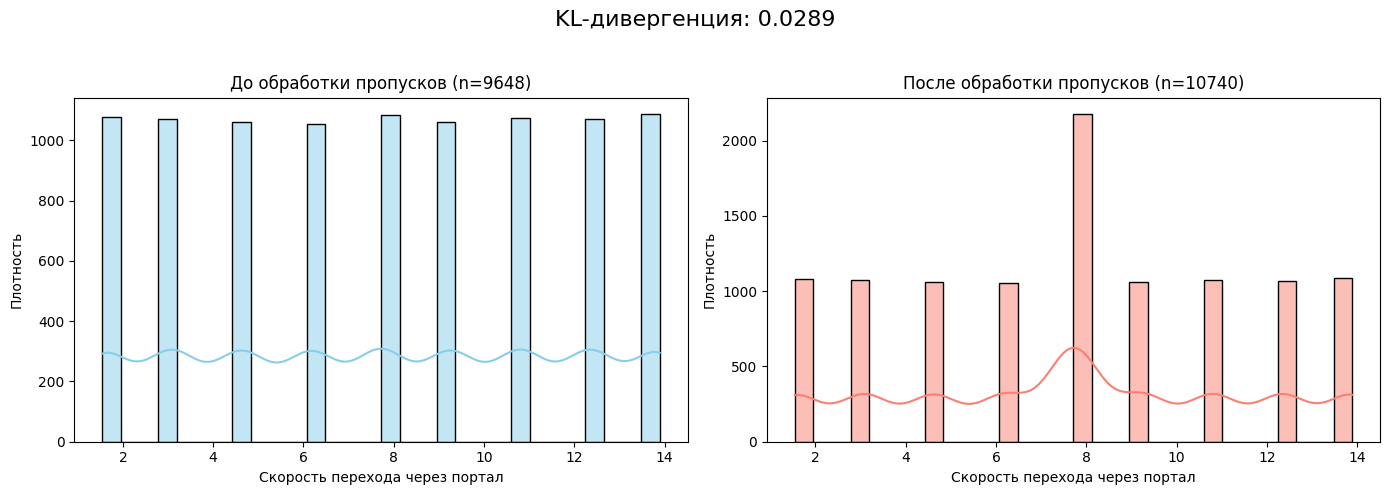

In [30]:
visualize_numeric_before_after(before=X_train['Скорость перехода через портал'], after=X_train_avg['Скорость перехода через портал'])

Сразу видно, что базовое распределение является равномерным, и замена пропущенных значений средник привела к изменения распределения.

Рассмотрим заполнение пропущенных значений `медианой`.

In [31]:
X_train_median = X_train.copy()
X_train_median

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи закодированный
5388,7.148,NaN,38997.064,280.444740,9121.068,332.380,332.380,839.126,736,2.979,15.755,45.060,0.892,0.973,4
5166,1.138,1.54332,3065.604,138.839965,6623.480,6.224,6.224,560.034,736,1.196,6.531,27.510,0.210,0.972,1
11024,9.300,13.88988,72755.957,372.838666,9725.267,644.718,644.718,1061.439,736,4.554,23.064,88.702,1.756,0.997,4
2644,8.206,12.34656,50996.924,323.332192,9314.395,438.130,438.130,937.401,736,3.578,18.520,61.330,1.214,0.961,4
4203,1.138,NaN,353.516,140.504380,6697.654,7.045,7.045,447.407,736,1.097,5.829,9.214,0.074,0.967,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,7.148,10.80324,38989.125,280.447358,9128.595,332.171,332.171,828.727,736,2.970,15.539,44.186,0.875,0.970,4
239,6.175,9.25992,29792.435,241.631934,8827.260,246.221,246.221,799.895,736,2.502,13.358,35.734,0.707,0.951,3
7196,6.175,9.25992,29789.783,241.639997,8815.603,246.177,246.177,763.815,736,2.507,13.154,33.618,0.666,0.980,3
1388,3.144,4.62996,8381.039,145.222005,7162.302,60.380,60.380,584.215,736,1.387,7.403,12.193,0.241,0.955,2


In [32]:
median_value = X_train_median['Скорость перехода через портал'].median()
X_train_median['Скорость перехода через портал'] = X_train_median['Скорость перехода через портал'].fillna(median_value)

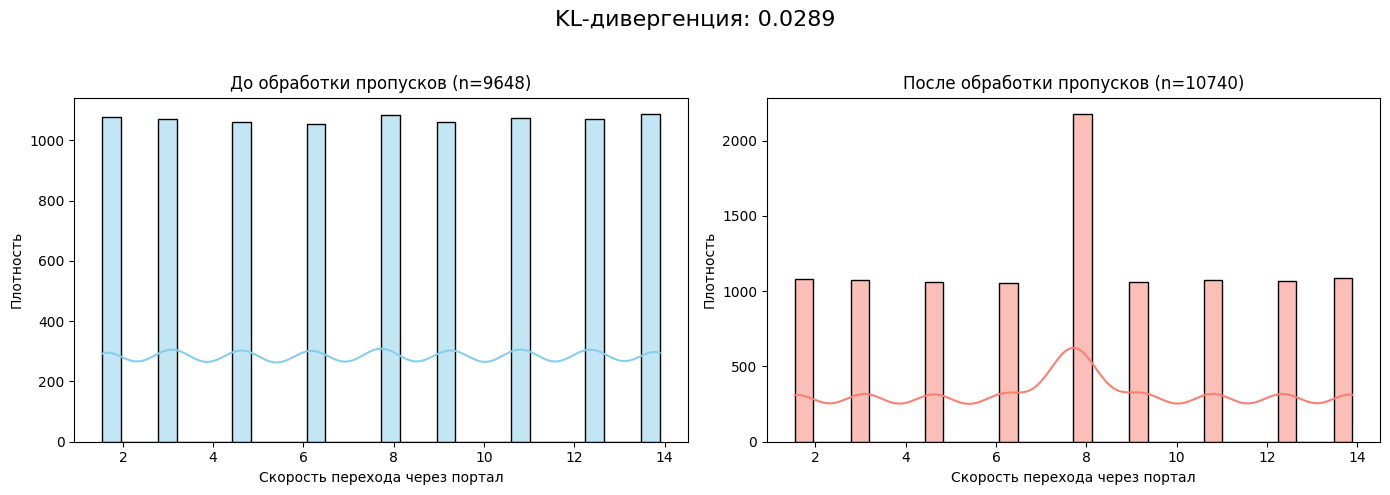

In [33]:
visualize_numeric_before_after(before=X_train['Скорость перехода через портал'], after=X_train_median['Скорость перехода через портал'])

После заполнения медианой мы получили тот же самый результат, т.к. медиана и среднее были приблизительно равны.

При рассмотрении статистического заполнения, можно взять как заполнение средним, так и заполнение медианой, посмотрим, что получиться после заполнения пропущенных значений при помощи машинных методов.

##### 1.1.5.1.2. <a id='toc1_1_5_1_2_'></a>[Заполнение пропущенных значений машинными подходами](#toc1_1_5_1_2_)

`Машинный подход`

Рассмотрим три варианта заполнения: `MICE`, `IterativeImputer`, `KNNImputer `. Для оценки качества этих подходов будет использована метрика `NRMSE`, с целью проверки корректности заполнения.

`NRMSE` (normalized root mean squared error) — нормализованная среднеквадратическая ошибка. Это относительная мера ошибок прогнозирования, которая позволяет сравнивать производительность моделей на разных наборах данных или в разных масштабах.

`NRMSE` вычисляется путём деления `RMSE` (среднеквадратической ошибки) на диапазон целевой переменной (разница между максимальным и минимальным значениями).

Чем меньше значение `NRMSE`, тем выше точность модели. Обычно хорошими считаются значения ниже `10%`, а показатели ниже `5%` указывают на отличную производительность.

$$NRMSE = \frac{RMSE}{X_{max} - X_{min}}$$
$$NRMSE = \frac{\sqrt(\frac{1}{N}*\sum(y_{i}-\widehat y_{i})^2}{X_{max} - X_{min}}$$

где:
- N - размер выборки;
- $y_{i}$ - реальное значение;
- $\widehat y_{i}$ - предсказанное значение;
- $X_{min}$ - минимальное значение в выборке;
- $X_{max}$ - максимальное значение в выборке.

Создам функцию, которая будет вычислять метрику `NRMSE`. 

In [34]:
from sklearn.metrics import mean_squared_error

def calculate_nrmse(original, imputed, mask):
    """
    Вычисляет Normalized Root Mean Square Error (NRMSE) для оценки качества импутации.
    
    Parameters:
    -----------
    original : array-like, pd.Series или pd.DataFrame
        Исходные данные без пропусков (истинные значения)
    imputed : array-like, pd.Series или pd.DataFrame  
        Данные после импутации (предсказанные значения)
    mask : array-like, pd.Series или pd.DataFrame
        Булева маска, где True указывает на позиции искусственных пропусков
        
    Returns:
    --------
    nrmse : float
        Значение NRMSE метрики
        - < 0.1: отличное качество
        - 0.1-0.2: хорошее качество
        - 0.2-0.3: удовлетворительное качество
        - > 0.3: низкое качество
    """
    
    # Преобразуем в numpy arrays для единообразия
    original_array = np.array(original)
    imputed_array = np.array(imputed)
    mask_array = np.array(mask)
    
    # Проверяем размерности
    if original_array.shape != imputed_array.shape:
        raise ValueError("Размерности original и imputed не совпадают")
    
    if original_array.shape != mask_array.shape:
        raise ValueError("Размерности original и mask не совпадают")
    
    # Извлекаем значения, которые были искусственно удалены
    original_masked = original_array[mask_array]
    imputed_masked = imputed_array[mask_array]
    
    # Проверяем, что есть значения для сравнения
    if len(original_masked) == 0:
        raise ValueError("Нет значений для сравнения. Проверьте маску.")
    
    # Вычисляем RMSE 
    rmse = np.sqrt(mean_squared_error(original_masked, imputed_masked))
    
    # Вычисляем диапазон исходных данных для нормализации
    data_range = np.max(original_array) - np.min(original_array)
    
    # Защита от деления на ноль
    try:
        if data_range == 0:
            return np.nan # Или 0, в зависимости от логики
        nrmse = rmse / data_range
    except ZeroDivisionError:
        print('Отсутствует диапазон значений')    
    
    return nrmse

Также создам функцию, которая создает искусственные пропуски в датасете для оценки методов машинного обучения. Функция принимает `data` - датасет без пропусков, у которого будем создавать искусственные пропуски, `missing_rate` - процент, сколько будет искусственных пропусков, `missing_type` - тип создания пропусков, принимает два значения, либо `MCAR` - полностью случайные пропуски, либо `MAR` - пропуски зависящие от другого признака, и опционально `dependent_feature` - признак от которого зависят пропуски, только в случае `MAR`.  

In [35]:
import numpy as np
import pandas as pd

def create_artificial_missing(data, missing_rate=0.1, random_state=SEED, missing_type='MCAR', dependent_feature=None):
    """
    Создает искусственные пропуски в данных для оценки методов импутации.
    
    Parameters:
    -----------
    data : pd.Series или pd.DataFrame
        Исходные данные без пропусков
    missing_rate : float
        Доля пропусков для создания (0-1)
    random_state : int
        Seed для воспроизводимости
    missing_type : str
        Тип пропусков: 
        - 'MCAR' (Missing Completely At Random) - полностью случайные
        - 'MAR' (Missing At Random) - зависящие от другого признака
    dependent_feature : pd.Series
        Признак, от которого зависят пропуски (только для MAR)
        
    Returns:
    --------
    masked_data : same type as input
        Данные с искусственными пропусками
    mask : np.array
        Булева маска, где True - созданные пропуски
    """
    np.random.seed(random_state)
    
    # Создаем копию данных
    masked_data = data.copy()
    
    if missing_type == 'MCAR':
        # Случайные пропуски
        mask = np.random.random(data.shape) < missing_rate
        
    elif missing_type == 'MAR':
        if dependent_feature is None:
            raise ValueError("Для MAR необходимо указать dependent_feature")
        
        # Нормализуем зависимый признак
        dep_normalized = (dependent_feature - dependent_feature.min()) / (dependent_feature.max() - dependent_feature.min())
        # Вероятность пропуска зависит от значений другого признака
        probabilities = dep_normalized * missing_rate * 2
        mask = np.random.random(data.shape) < probabilities
        
    else:
        raise ValueError("missing_type должен быть 'MCAR' или 'MAR'")
    
    # Применяем маску к данным
    if isinstance(masked_data, pd.DataFrame):
        masked_data = masked_data.where(~mask, np.nan)
    else:  # pd.Series
        masked_data[mask] = np.nan
    
    print(f"Создано искусственных пропусков: {mask.sum()} ({mask.sum()/mask.size:.1%})")
    
    return masked_data, mask

##### 1.1.5.1.2.1. <a id='toc1_1_5_1_2_1_'></a>[Заполнение пропущенных значений методом MICE](#toc1_1_5_1_2_1_)

`MICE` (Multiple Imputation by Chained Equations) — алгоритм машинного обучения, который заполняет пропущенные данные с помощью итерационной серии прогнозирующих моделей. Также называется «множественной импутацией с помощью цепных уравнений».

In [36]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [37]:
clean_data = X_train.dropna(subset=['Скорость перехода через портал']).copy()
masked_values, mask = create_artificial_missing(
        clean_data, 
        missing_rate=0.1
    )
clean_data

Создано искусственных пропусков: 14555 (10.1%)


,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи закодированный
5166,1.138,1.54332,3065.604,138.839965,6623.480,6.224,6.224,560.034,736,1.196,6.531,27.510,0.210,0.972,1
11024,9.300,13.88988,72755.957,372.838666,9725.267,644.718,644.718,1061.439,736,4.554,23.064,88.702,1.756,0.997,4
2644,8.206,12.34656,50996.924,323.332192,9314.395,438.130,438.130,937.401,736,3.578,18.520,61.330,1.214,0.961,4
11505,4.161,6.17328,14716.713,162.047538,7691.159,113.723,113.723,635.555,736,1.667,9.017,17.047,0.337,0.999,2
6437,3.144,4.62996,8377.236,145.219806,7083.643,60.336,60.336,583.088,736,1.390,7.491,12.191,0.241,0.977,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,7.148,10.80324,38989.125,280.447358,9128.595,332.171,332.171,828.727,736,2.970,15.539,44.186,0.875,0.970,4
239,6.175,9.25992,29792.435,241.631934,8827.260,246.221,246.221,799.895,736,2.502,13.358,35.734,0.707,0.951,3
7196,6.175,9.25992,29789.783,241.639997,8815.603,246.177,246.177,763.815,736,2.507,13.154,33.618,0.666,0.980,3
1388,3.144,4.62996,8381.039,145.222005,7162.302,60.380,60.380,584.215,736,1.387,7.403,12.193,0.241,0.955,2


In [38]:
data_for_mice = clean_data.copy()

In [39]:
mice_imputer = IterativeImputer(random_state=42, max_iter=10)

# Важно: MICE работает на таблицах, поэтому подаем весь DataFrame
# Он вернет numpy-массив, поэтому превратим его обратно в DataFrame
imputed_array = mice_imputer.fit_transform(masked_values)
imputed_data = pd.DataFrame(imputed_array, columns=masked_values.columns, index=masked_values.index)

In [40]:
# Сравниваем оригинал (clean_data) и то, что получилось (imputed_data)
error = calculate_nrmse(clean_data, imputed_data, mask)

print(f"NRMSE для MICE: {error:.4f}")

NRMSE для MICE: 0.0011


Значение метрики `NRMSE` для MICE очень низкое, это означает прекрасную работу этого алгоритма. 

##### 1.1.5.1.2.2. <a id='toc1_1_5_1_2_2_'></a>[Заполнение пропущенных значений методом KNNImputer](#toc1_1_5_1_2_2_)

In [41]:
from sklearn.impute import KNNImputer

In [42]:
knn_imputer = KNNImputer(n_neighbors=5)

knn_array = knn_imputer.fit_transform(masked_values)
knn_data = pd.DataFrame(knn_array, columns=masked_values.columns, index=masked_values.index)

In [43]:
error_knn = calculate_nrmse(clean_data, knn_data, mask)

print(f"NRMSE для KNN: {error_knn:.4f}")

NRMSE для KNN: 0.0019


NRMSE для KNN тоже очень низкий, значит алгоритм работает также хорошо как и mice, чтобы понять, какой из них лучше, проверим их на реальных данных, как они изменять распределение.

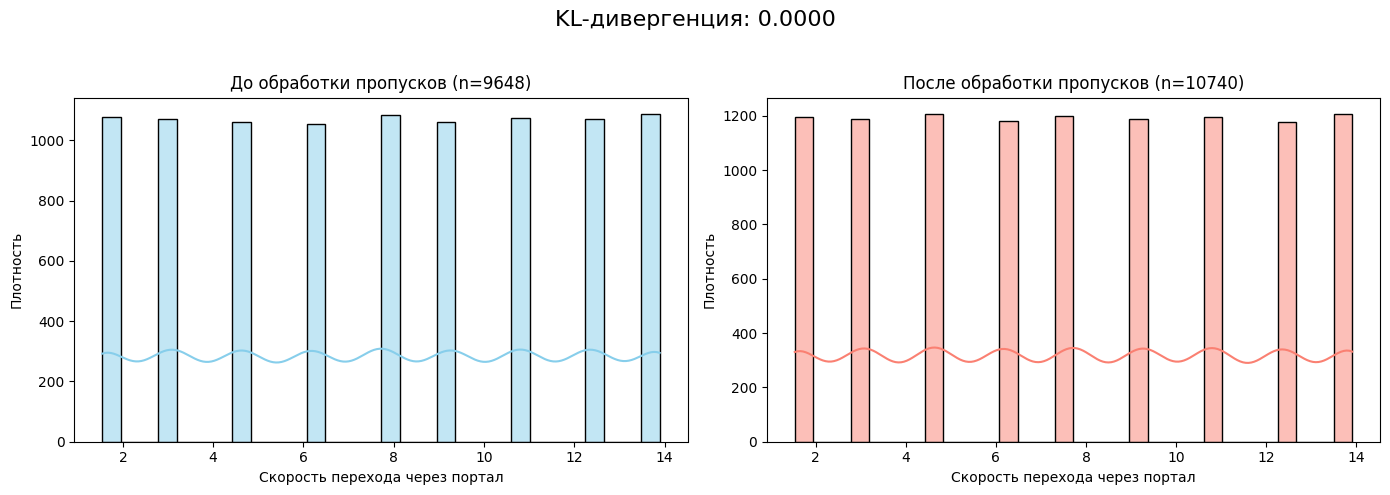

In [44]:
X_train_mice = mice_imputer.transform(X_train)
X_train_mice = pd.DataFrame(X_train_mice, columns=X_train.columns, index=X_train.index)
visualize_numeric_before_after(before=X_train['Скорость перехода через портал'], after=X_train_mice['Скорость перехода через портал'])

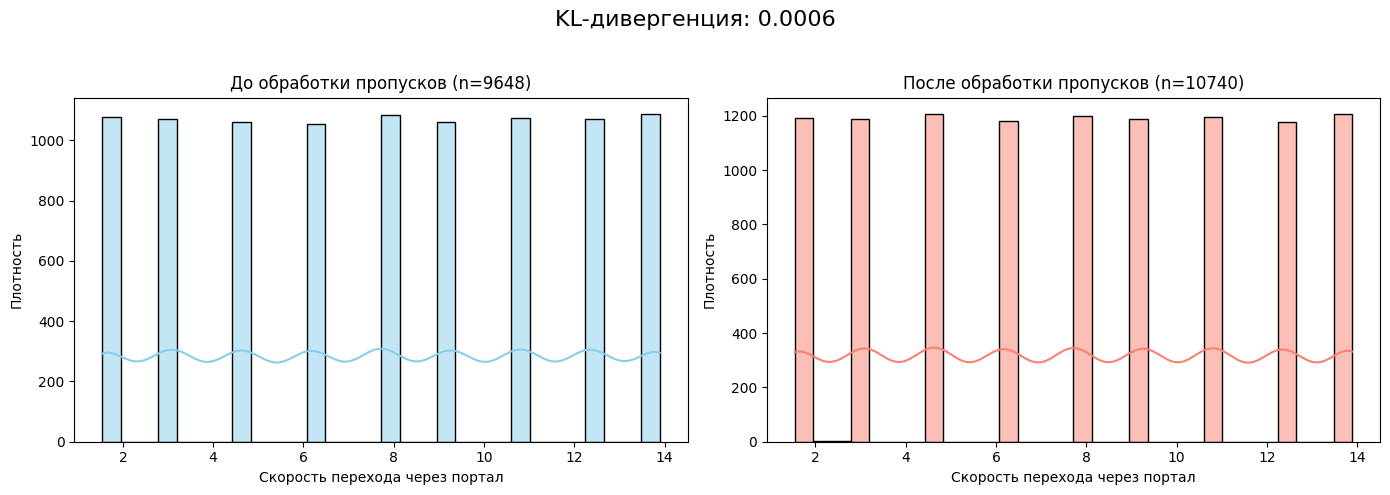

In [45]:
X_train_knn = knn_imputer.transform(X_train)
X_train_knn = pd.DataFrame(X_train_knn, columns=X_train.columns, index=X_train.index)
visualize_numeric_before_after(before=X_train['Скорость перехода через портал'], after=X_train_knn['Скорость перехода через портал'])

Прекрасные результаты, MICE подходим лучше всего, низкая KL-дивергенция, низкое значение NRMSE метрики, а также сохранение распределения. К данным на X_train будет применен MICE.

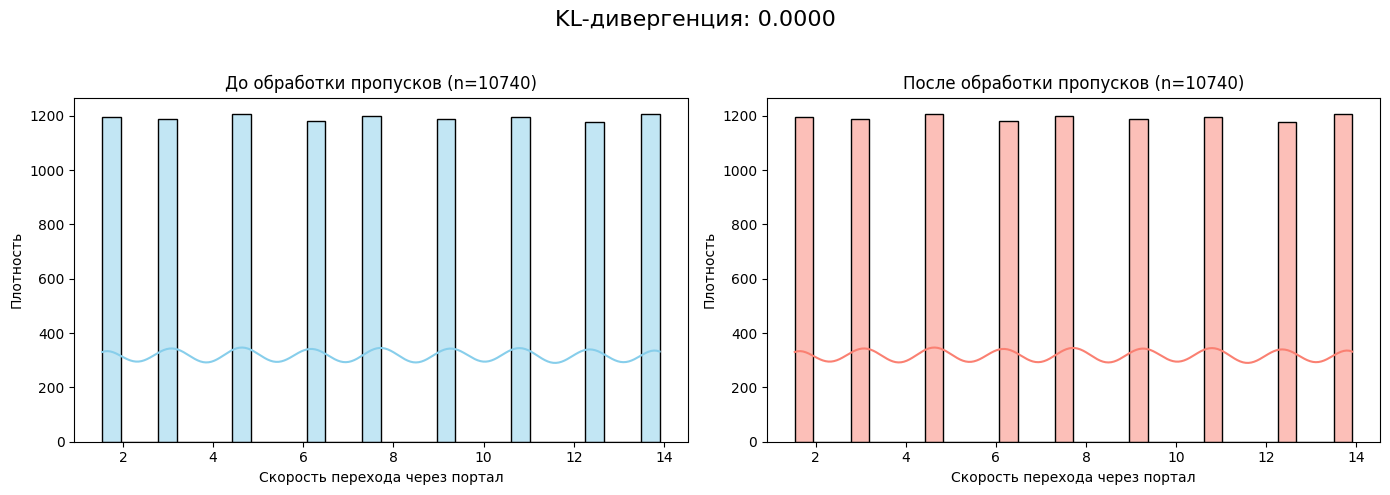

(10740, 15)

In [46]:
X_train_imputed = mice_imputer.transform(X_train)
X_train = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
visualize_numeric_before_after(before=X_train['Скорость перехода через портал'], after=X_train['Скорость перехода через портал'])
X_train.shape

### 1.1.6. <a id='toc1_1_6_'></a>[Устранение проблемы наличия выбросов и аномалий в данных](#toc1_1_6_)

Часто наличие аномалий и выбросов в данных может привести к непредсказуемым результатам обученя моделей: слишком непохожие на подавляющее большинство объектов значения меняют веса, в результате чего теряется обобщающая способность.

#### 1.1.6.1. <a id='toc1_1_6_1_'></a>[Устранение проблемы наличия выбросов в данных](#toc1_1_6_1_)

Выбросы в данных -- это значения, которые сильно отличаются от остальных значений внутри признака.

Выбросы могут привести к искажению результатов исследования зависимостей в данных, так как они могут значительно влиять на статистические характеристики. Кроме того, некоторые алгоритмы машинного обучения могут быть чувствительны к выбросам, и их наличие может привести к неправильным предсказаниям моделей регрессии.

Поэтому необходимо выявить выбросы внутри каждого признака и избавиться от объектов, которые в своем разложении имеют выбросы.

In [47]:
def visualize_hist_box(X_train: pd.DataFrame):
    """
    Визуализирует гистограммы и boxplots для всех признаков в X_train.
    """
    cols = X_train.columns

    for col in cols:
        plt.figure(figsize=(12, 4))
        
        # Левый график: Гистограмма
        plt.subplot(1, 2, 1)
        sns.histplot(X_train[col], kde=True, color='skyblue', log=True)
        plt.title(f'Распределение: {col}')
        
        # Правый график: Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=X_train[col], color='salmon')
        plt.title(f'Boxplot: {col}')
        
        plt.tight_layout()
        plt.show()

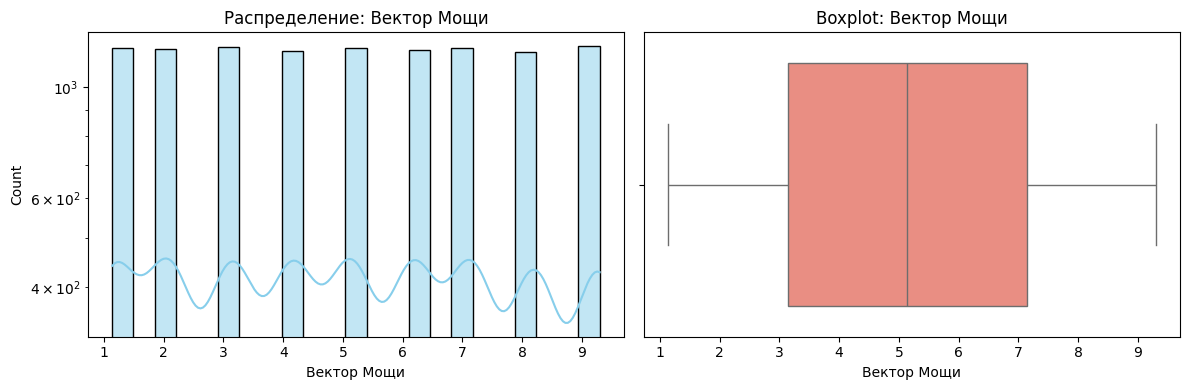

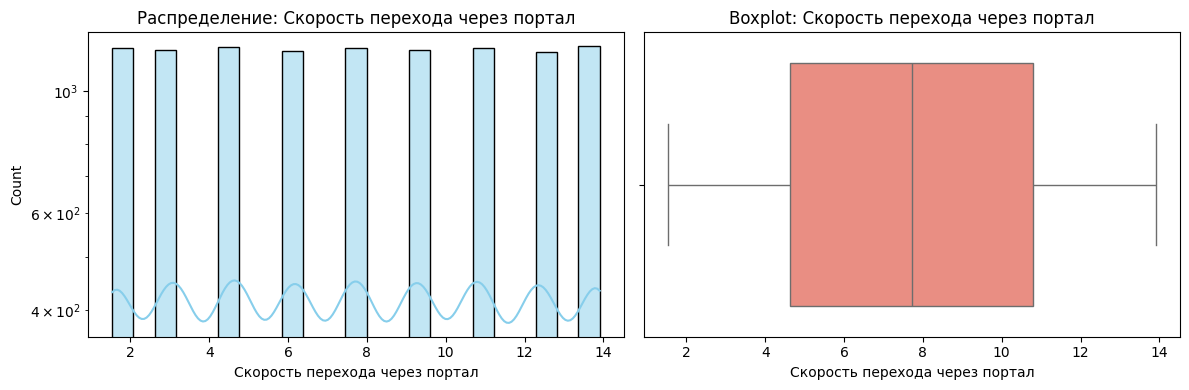

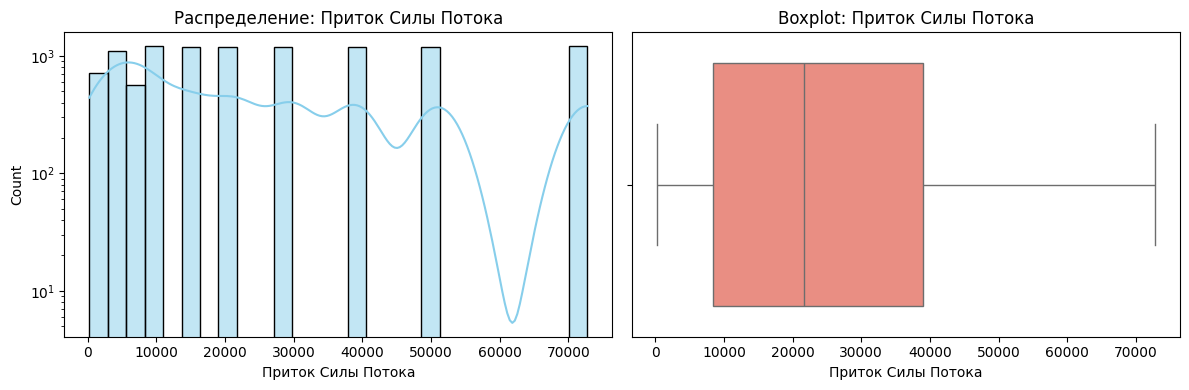

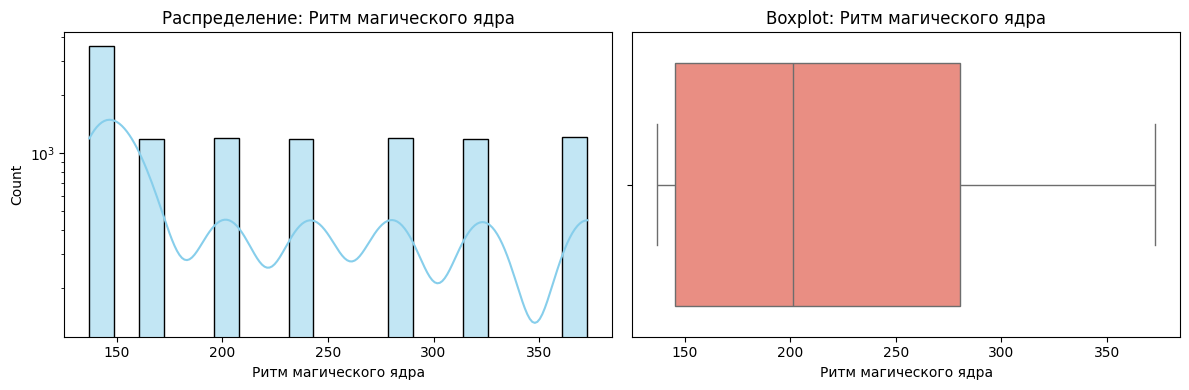

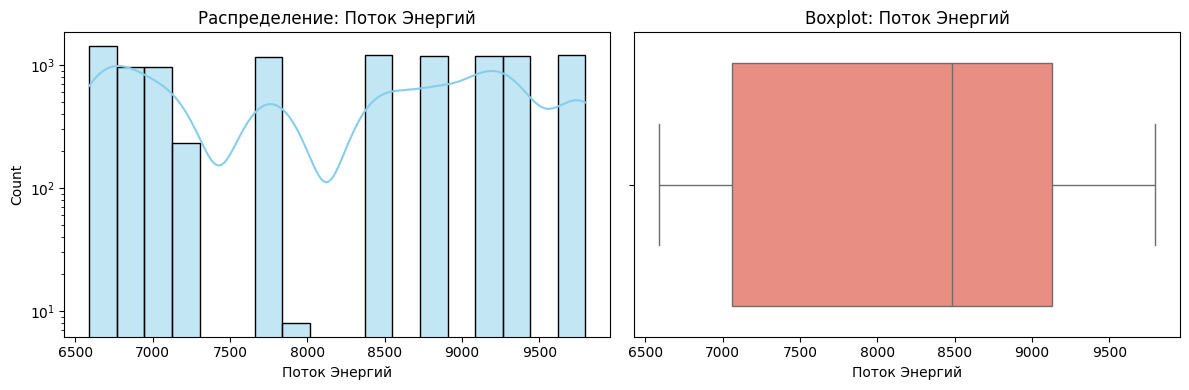

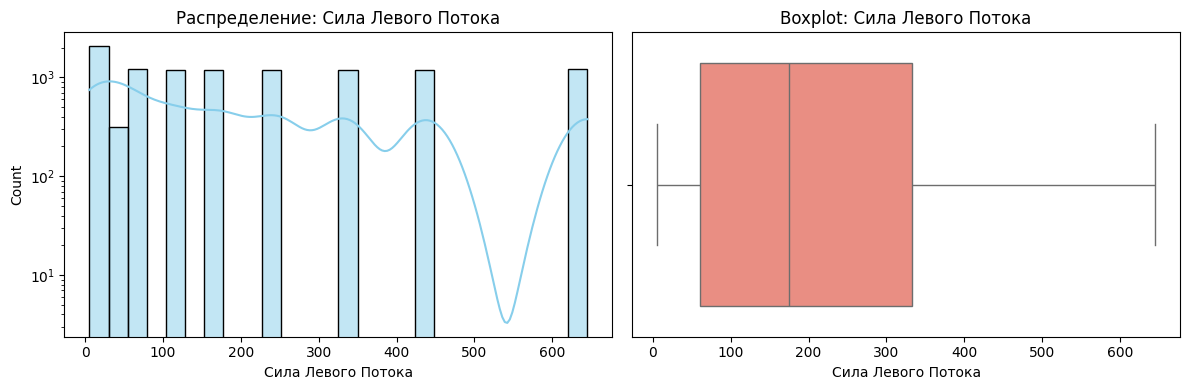

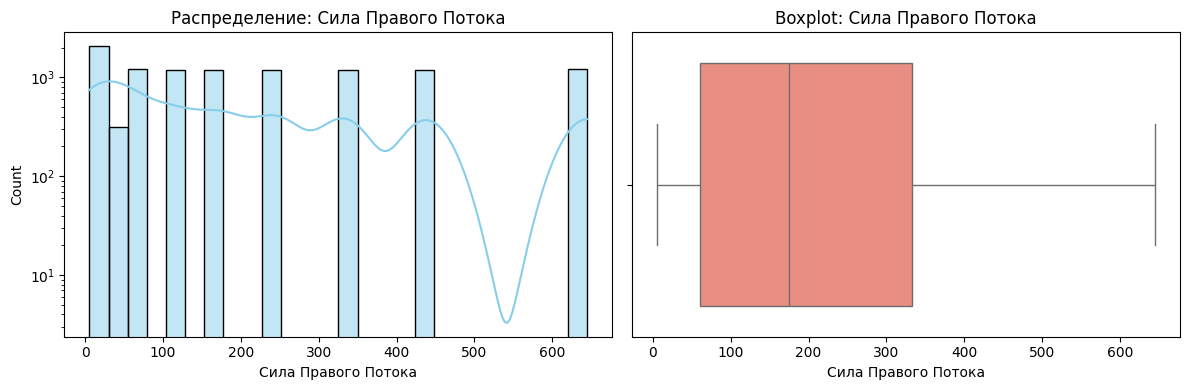

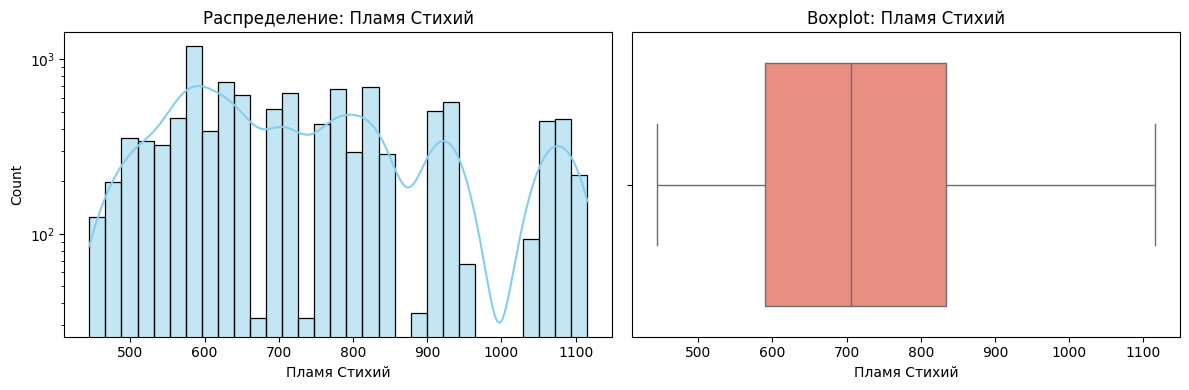

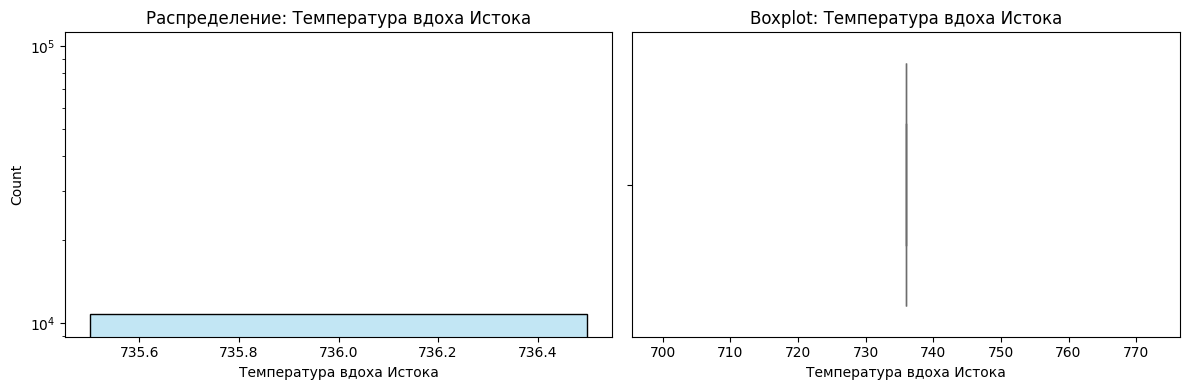

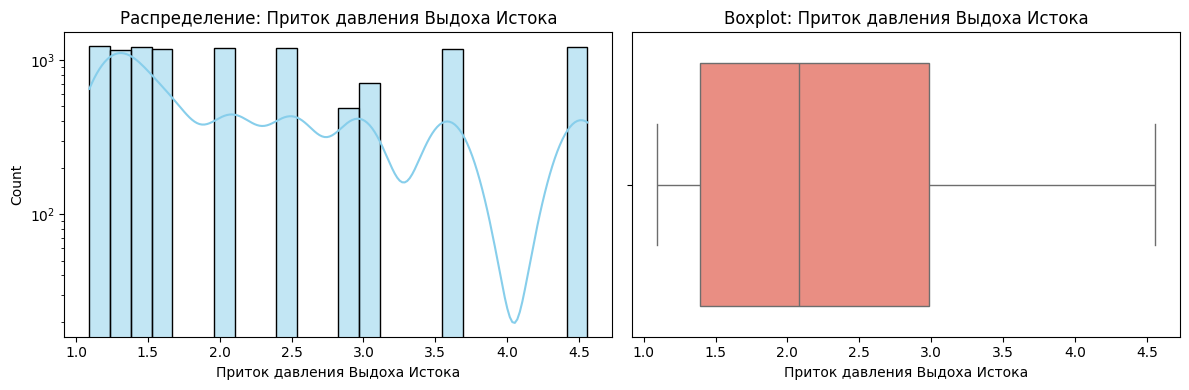

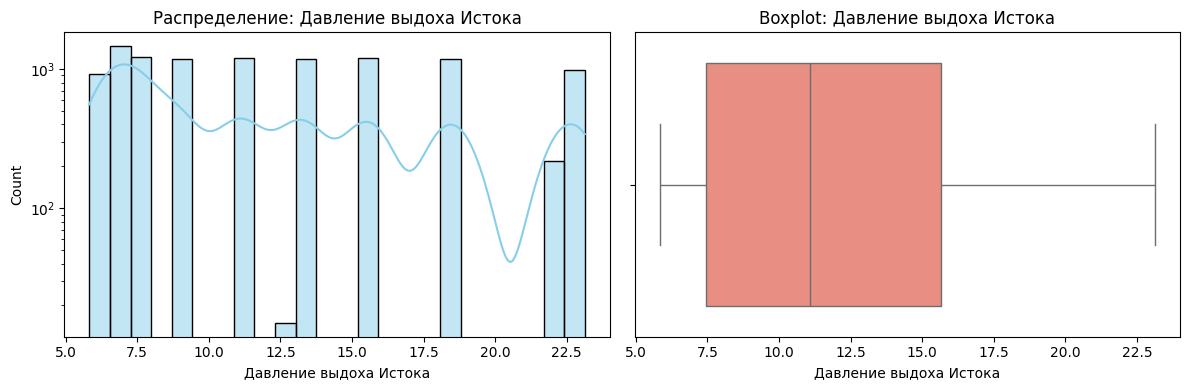

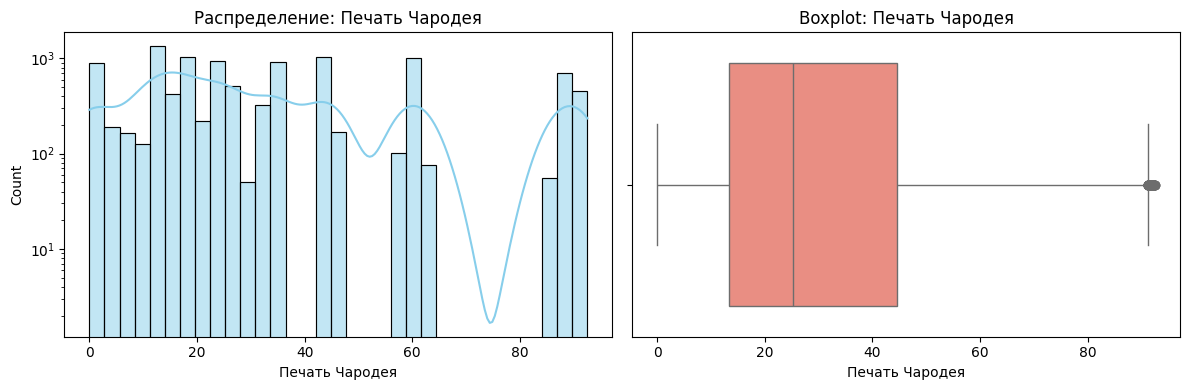

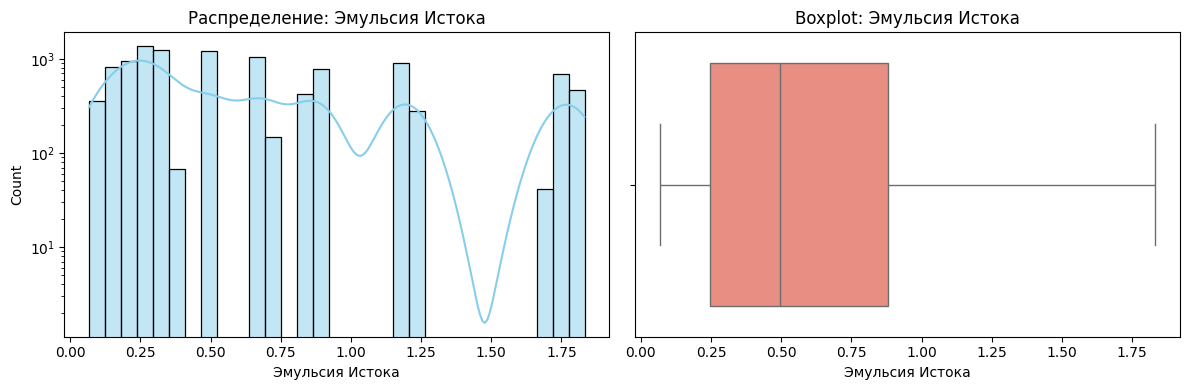

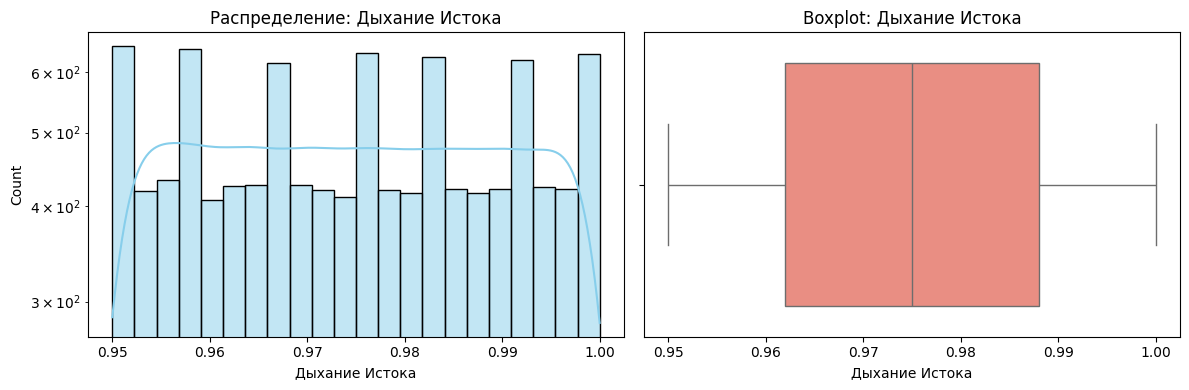

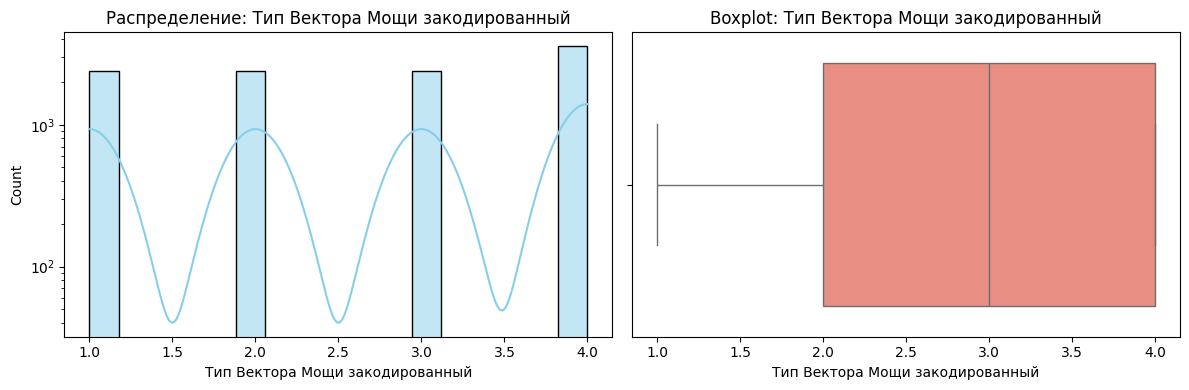

In [48]:
visualize_hist_box(X_train)

Изучив графики распределения и boxplotы можно точно сказать, что лишь 1 признак `Печать чародея` имеет выбросы. Также стоит обратить внимание на такой признак как `Температура вдоха стихии`, скорее всего признак является константой, т.е. все кортежи содержать лишь 1 значение. В целом, можно заметить, что в большинстве признаки имеют небольшое смещение в одну из сторон, также распределение у большинства признаков - равномерное, но учитывая график `ящик с усами` данных признаков, можно сказать, что все эти признаки вписываются в картину "нормальные данные", т.е. не имеют выбросов. 

Для начала рассмотрим признак `Температура вдоха стихии`, чтобы больше к нему не возвращаться.

In [49]:
X_train['Температура вдоха Истока'].unique()

array([736.])

In [50]:
X_test['Температура вдоха Истока'].unique()

array([736])

Видим, что признак `Температура вдоха стихии` в обоих выборках и в правду содержит лишь 1 уникальное значение, значит смело избавляемся от этого признака, т.к. для обучения модели, этот признак не несет никакой информативности.

In [51]:
X_train = X_train.drop('Температура вдоха Истока', axis=1)
X_test = X_test.drop('Температура вдоха Истока', axis=1)
X_train

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи закодированный
5388,7.148,10.772147,38997.064,280.444740,9121.068,332.380,332.380,839.126,2.979,15.755,45.060,0.892,0.973,4.0
5166,1.138,1.543320,3065.604,138.839965,6623.480,6.224,6.224,560.034,1.196,6.531,27.510,0.210,0.972,1.0
11024,9.300,13.889880,72755.957,372.838666,9725.267,644.718,644.718,1061.439,4.554,23.064,88.702,1.756,0.997,4.0
2644,8.206,12.346560,50996.924,323.332192,9314.395,438.130,438.130,937.401,3.578,18.520,61.330,1.214,0.961,4.0
4203,1.138,1.583157,353.516,140.504380,6697.654,7.045,7.045,447.407,1.097,5.829,9.214,0.074,0.967,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4794,7.148,10.803240,38989.125,280.447358,9128.595,332.171,332.171,828.727,2.970,15.539,44.186,0.875,0.970,4.0
239,6.175,9.259920,29792.435,241.631934,8827.260,246.221,246.221,799.895,2.502,13.358,35.734,0.707,0.951,3.0
7196,6.175,9.259920,29789.783,241.639997,8815.603,246.177,246.177,763.815,2.507,13.154,33.618,0.666,0.980,3.0
1388,3.144,4.629960,8381.039,145.222005,7162.302,60.380,60.380,584.215,1.387,7.403,12.193,0.241,0.955,2.0


##### 1.1.6.1.1. <a id='toc1_1_6_1_1'></a>[Квартильный анализ (IQR)](#toc1_1_6_1_1_)

Квартильный анализ (IQR) — это метод, котоырй используется для выявления выбросов на основе квартильного размаха.

Процентиль уровня $q$ -- это такое значение $x_q$ случайной величины $X$, что $P(X < x_q) = q$.

Квартили — это значения, которые делят упорядоченный набор данных на четыре равные части:

- Q1 (первый квартиль): 25-й процентиль, ниже которого находится 25% данных.
- Q2 (второй квартиль): 50-й процентиль, также известный как медиана, ниже которой находится 50% данных.
- Q3 (третий квартиль): 75-й процентиль, ниже которого находится 75% данных.

Межквартильный размах (IQR) — это разница между третьим и первым квартилями: IQR = Q3 − Q1. IQR используется для оценки рассеивания данных и является более устойчивым к выбросам по сравнению с дисперсией или стандартным отклонением.

Алгоритм поиска выбросов:
1. для данного признака вычисляется Q1, Q3 и IQR;
2. определяются границы выбросов:
    - нижняя граница: Q1 - 1.5 $\cdot$ IQR
    - верхняя граница: Q1 + 1.5 $\cdot$ IQR
3. значения, которые меньше нижней границы или больше верхней границы, считаются выбросами.

Для начала создадим функцию для вычисления границ

In [52]:
def calc_bounds(x: t.Iterable[float]) -> t.Tuple[float, float]:
    """Вычисление левой и правой границ IQR

    Args:
        x (t.Iterable[float]): Вариационный ряд

    Returns:
        t.Tuple[float, float]: Левая и правая границы
    """
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

Также реализуем функцию, которая проверяет, содержит ли вариационный ряд выбросы.

In [53]:
def check_feature_outliers_iqr(x: pd.Series) -> np.ndarray[bool]:
    """Проверка выбросов при помощи IQR

    Args:
        x (pd.Series): Вариационный ряд

    Returns:
        np.ndarray[bool]: Массив меток для каждого объекта вариационного ряда, является ли значение выбросом
    """
    lower_bound, upper_bound = calc_bounds(x)
    return ((x < lower_bound) | (x > upper_bound)).values

И, наконец, реализуем функцию, которая проверяет, содержит ли объект датасета выброс внутри своего разложения в признаковом пространстве. Данная функция обобщает методы исследования, поэтому принимает в качестве аргумента outliers_method: алгоритм вычисления выбросов.

In [54]:
def check_dataset_outliers(df: pd.DataFrame, outliers_method: t.Callable[..., np.ndarray[bool]], **kwargs) -> np.ndarray[bool]:
    """Проверка выбросов у объектов датасета

    Args:
        df (pd.DataFrame): Датасет
        outliers_method (t.Callable[..., np.ndarray[bool]]): Правило детектирования выбросов

    Returns:
        np.ndarray[bool]: Массив меток для каждого объекта датасета, содержит ли объект выбросы
    """
    outliers_flags = [
        outliers_method(df[column], **kwargs) for column in df.columns
    ]
    return np.any(np.array(outliers_flags), axis=0)

Проверим набор данных при помощи данного алгоритма и выведем только те строки, которые были помечены, как выбросы.

In [55]:
outliers_objects_iqr = X_train.loc[check_dataset_outliers(X_train, check_feature_outliers_iqr)]
outliers_objects_iqr

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи закодированный
1223,9.3,13.889880,72766.446,372.845054,9776.570,645.061,645.061,1105.408,4.498,22.707,91.627,1.814,0.955,4.0
2132,9.3,13.889880,72763.501,372.843483,9769.450,644.819,644.819,1103.446,4.506,22.815,91.631,1.814,0.959,4.0
2843,9.3,13.889880,72764.227,372.843169,9766.735,645.079,645.079,1099.082,4.509,22.807,91.291,1.807,0.962,4.0
1421,9.3,13.889880,72762.415,372.843902,9772.179,644.822,644.822,1107.834,4.504,22.823,91.974,1.821,0.956,4.0
2609,9.3,13.889880,72763.544,372.844007,9767.901,645.062,645.062,1100.230,4.508,22.800,91.368,1.809,0.961,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457,9.3,13.889880,72766.237,372.844635,9775.395,645.041,645.041,1104.238,4.499,22.713,91.548,1.812,0.956,4.0
1916,9.3,13.889880,72764.502,372.844844,9772.240,644.759,644.759,1102.803,4.503,22.753,91.496,1.811,0.958,4.0
3059,9.3,13.889880,72762.074,372.842331,9763.890,645.068,645.068,1099.735,4.513,22.869,91.426,1.810,0.963,4.0
2393,9.3,13.889880,72765.359,372.844844,9770.703,644.785,644.785,1099.591,4.504,22.739,91.233,1.806,0.960,4.0


При помощи IQR, мы вычислили, что 114 объектов содержать выбросы в данных. Рассмотрим ещё 1 метод.

##### 1.1.6.1.2. <a id='toc1_1_6_1_2'></a>[Robust Z-score](#toc1_1_6_1_2_)

### Метод Robust Z-score

**Robust Z-score** (или модифицированный Z-score) — это статистический метод обнаружения выбросов, который, подобно IQR, устойчив к экстремальным значениям, так как использует медиану вместо среднего арифметического.

Классический Z-score сильно зависит от выбросов, потому что они «раздувают» среднее значение и стандартное отклонение. Robust Z-score решает эту проблему, заменяя их на робастные (устойчивые) аналоги.

#### Основные понятия
* **Медиана (Median)** — значение, которое делит упорядоченный набор данных пополам. Это 50-й процентиль.
* **Медианное абсолютное отклонение (MAD)** — это мера разброса данных, которая вычисляется как медиана абсолютных отклонений каждого значения от общей медианы набора.
    * **Формула:** $$MAD = \text{median}(|x_i - \text{median}(X)|)$$

#### Алгоритм поиска выбросов
1.  Для данного признака вычисляются **Медиана** и **MAD**.
2.  Вычисляется **Robust Z-score** для каждого значения по формуле:
    $$Z_{robust} = \frac{0.6745 \cdot (x_i - \text{Median})}{MAD}$$
    *(Коэффициент 0.6745 используется для того, чтобы MAD был сопоставим со стандартным отклонением при нормальном распределении).*
3.  Определяется **порог (threshold)** — обычно это значение **3** или **3.5**.
4.  Значения, для которых $|Z_{robust}| > \text{threshold}$, считаются **выбросами**.

Реализуем функцию, которая проверяет, содержит ли вариационный ряд выбросы на основе Robust Z-score

In [56]:
def check_feature_outliers_robust_z(x: pd.Series, threshold: float = 3.0) -> np.ndarray[bool]:
    """Проверка выбросов при помощи Robust Z-score
    
    Args:
        x (pd.Series): Вариационный ряд
        threshold (float): Порог (коэффициент), выше которого значение считается выбросом. Обычно используется 3.0 или 3.5.

    Returns:
        np.ndarray[bool]: Массив меток выбросов
    """
    median = x.median()
    # Рассчитываем MAD (Медианное абсолютное отклонение)
    mad = np.median(np.abs(x - median))
    
    # Защита от деления на ноль для константных признаков
    if mad == 0:
        return np.zeros(len(x), dtype=bool)
    
    # Вычисляем модифицированный Z-score
    robust_z_scores = 0.6745 * (x - median) / mad
    
    return (np.abs(robust_z_scores) > threshold).values

Проверим набор данных при помощи данного алгоритма и выведем только те строки, которые были помечены, как выбросы.

In [57]:
outliers_objects_z = X_train.loc[check_dataset_outliers(X_train, check_feature_outliers_robust_z)]
outliers_objects_z

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи закодированный
11024,9.3,13.889880,72755.957,372.838666,9725.267,644.718,644.718,1061.439,4.554,23.064,88.702,1.756,0.997,4.0
9134,9.3,13.889880,72755.820,372.839713,9732.545,644.793,644.793,1071.745,4.546,23.067,89.522,1.772,0.989,4.0
9728,9.3,13.889880,72767.429,372.844007,9743.141,644.750,644.750,1057.266,4.532,22.698,87.881,1.740,0.991,4.0
5516,9.3,13.889880,72772.326,372.845054,9763.146,645.091,645.091,1076.903,4.509,22.580,89.267,1.767,0.973,4.0
413,9.3,13.889880,72777.624,372.847881,9791.735,645.057,645.057,1097.820,4.476,22.303,90.483,1.791,0.951,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,9.3,13.903008,72774.979,372.847777,9789.971,644.927,644.927,1102.466,4.479,22.404,90.975,1.801,0.950,4.0
5543,9.3,13.889880,72774.310,372.845996,9765.607,644.920,644.920,1074.321,4.506,22.500,88.954,1.761,0.973,4.0
10142,9.3,13.889880,72761.733,372.842331,9735.481,645.061,645.061,1060.356,4.542,22.874,88.361,1.749,0.993,4.0
11087,9.3,13.889880,72761.941,372.841493,9731.913,645.008,645.008,1055.243,4.545,22.873,87.954,1.741,0.997,4.0


Видим, что этот метод выявил в 10 раз больше записей с выбросами, но такое не удивительно, т.к. наши данные не "идеальные", и многие признаки имеют смещение, от чего показатель имеет такую разницу со стандартным IQR.

Т.к. эти методы опираются на разные статистики для выявления выбросов, из нашей тренировочной выборки мы удалим те записи, которые содержаться сразу в 2 методах, т.е. оба метода говорят: "Это выброс".

In [58]:
# Находим общие индексы
common_indices = np.intersect1d(
    outliers_objects_iqr.index,
    outliers_objects_z.index
)

# Извлекаем строки по этим индексам
intersection_outliers = X_train.loc[common_indices]
intersection_outliers

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи закодированный
8,9.3,13.88988,72763.329,372.843693,9778.528,644.905,644.905,1115.797,4.498,22.811,92.556,1.832,0.950,4.0
17,9.3,13.90537,72763.515,372.844321,9779.311,644.963,644.963,1114.887,4.496,22.784,92.448,1.830,0.950,4.0
26,9.3,13.88988,72764.565,372.844530,9780.103,645.076,645.076,1113.985,4.495,22.756,92.342,1.828,0.950,4.0
44,9.3,13.88988,72766.645,372.844740,9781.672,644.879,644.879,1112.188,4.493,22.701,92.129,1.824,0.950,4.0
53,9.3,13.88988,72767.018,372.845473,9782.442,644.844,644.844,1111.290,4.492,22.674,92.023,1.822,0.950,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3518,9.3,13.88988,72760.520,372.842122,9760.674,644.733,644.733,1098.348,4.516,22.909,91.377,1.809,0.965,4.0
3527,9.3,13.88988,72761.533,372.842226,9761.520,644.812,644.812,1097.442,4.515,22.882,91.270,1.807,0.965,4.0
3752,9.3,13.88988,72760.410,372.842017,9759.488,645.059,645.059,1097.206,4.518,22.916,91.300,1.807,0.966,4.0
3761,9.3,13.88988,72761.662,372.842122,9760.342,645.055,645.055,1096.302,4.516,22.888,91.193,1.805,0.966,4.0


Заметим, что объединение содержит 114 записей, значит все записи, которые были выявлены при помощи IQR, входят в выбросы, выявленные при помощи Robust Z-score

In [59]:
# Удаляем строки из обучающей выборки
X_train = X_train.drop(index=common_indices)

# Удаляем те же строки из целевой переменной 
y_train = y_train.drop(index=common_indices)
X_train.shape

(10626, 14)

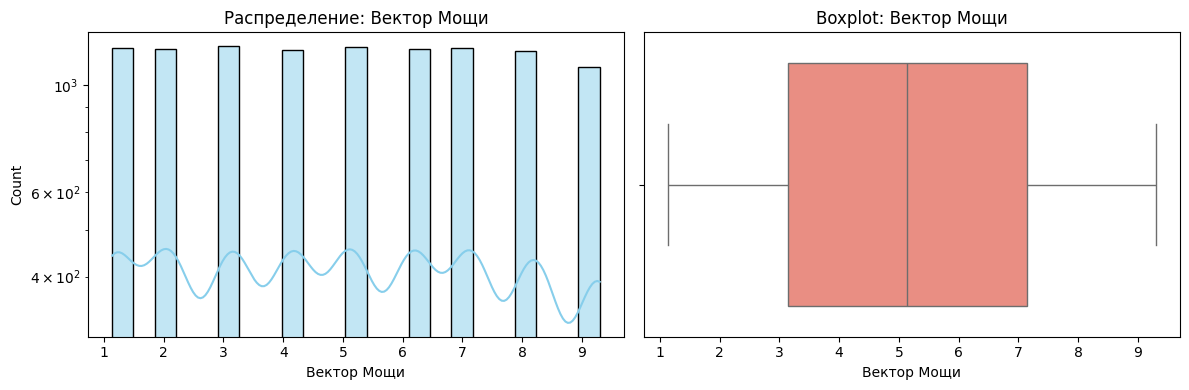

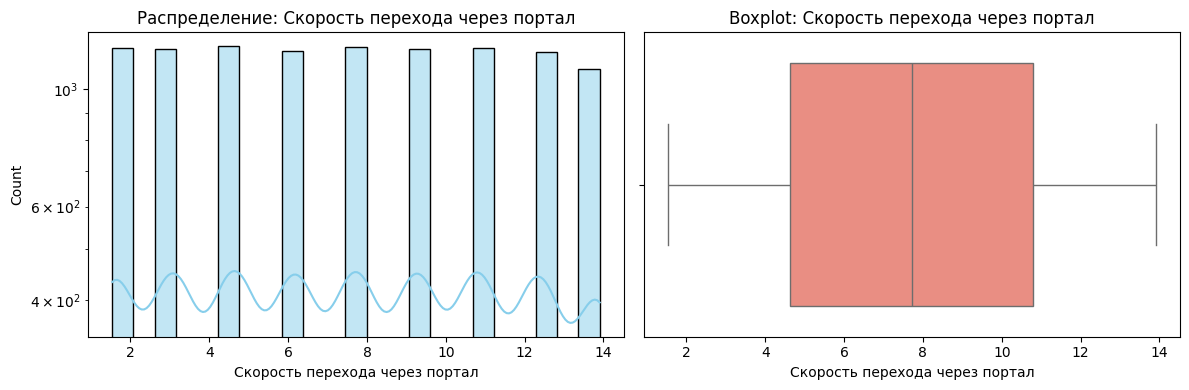

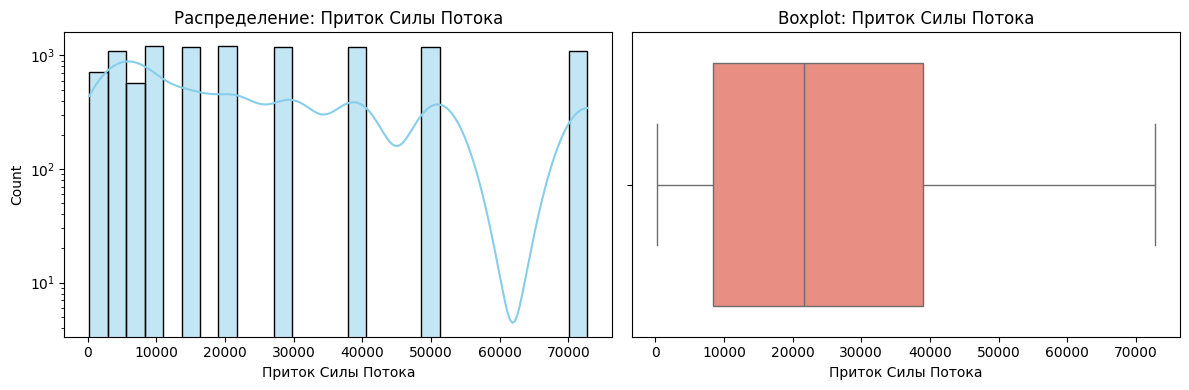

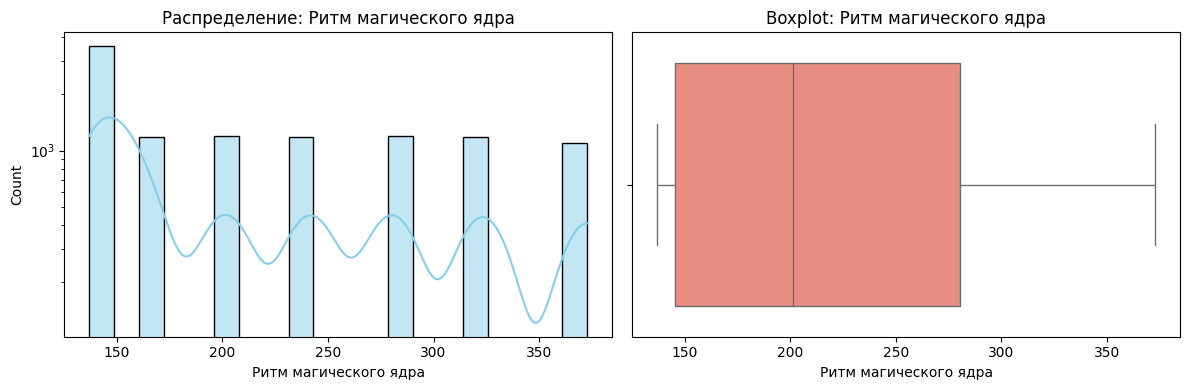

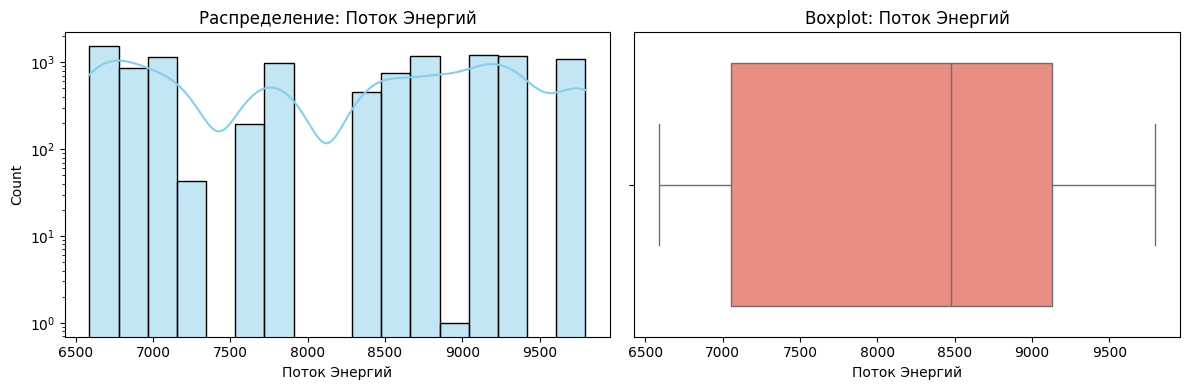

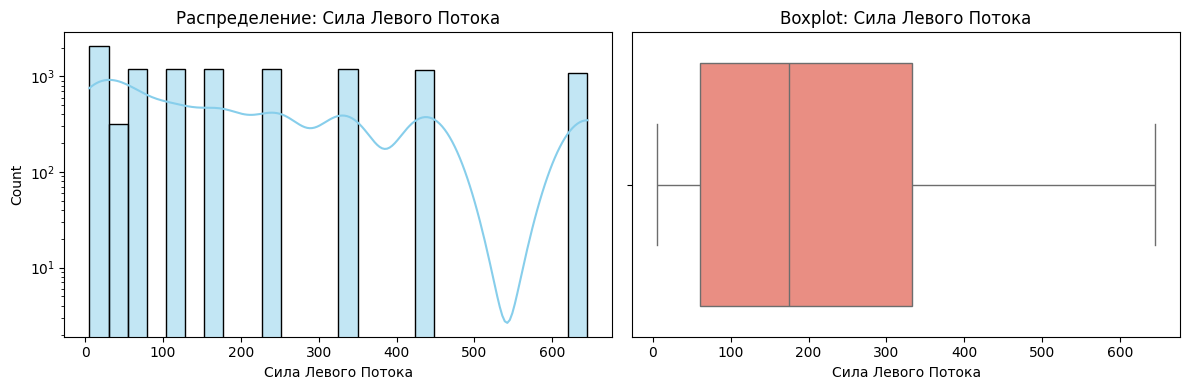

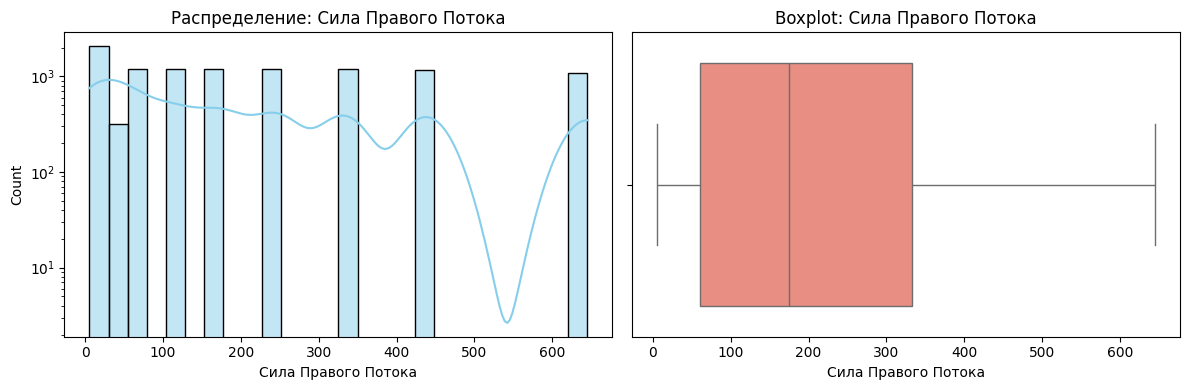

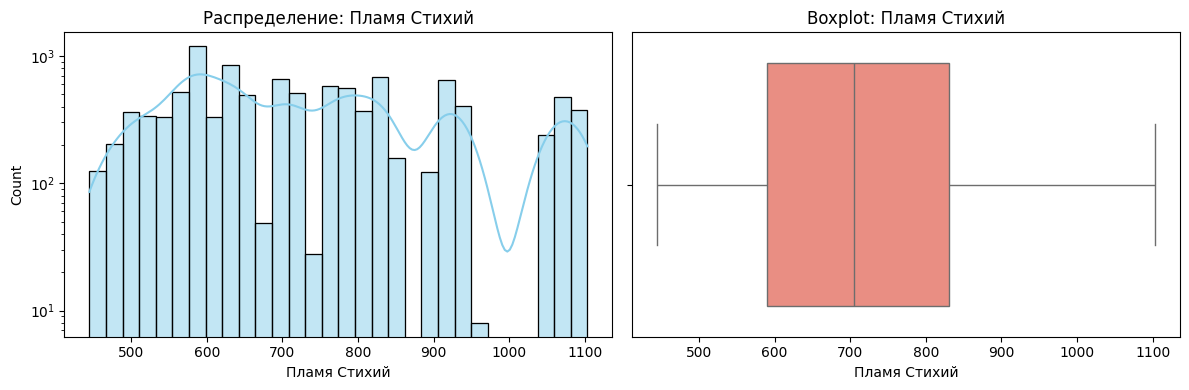

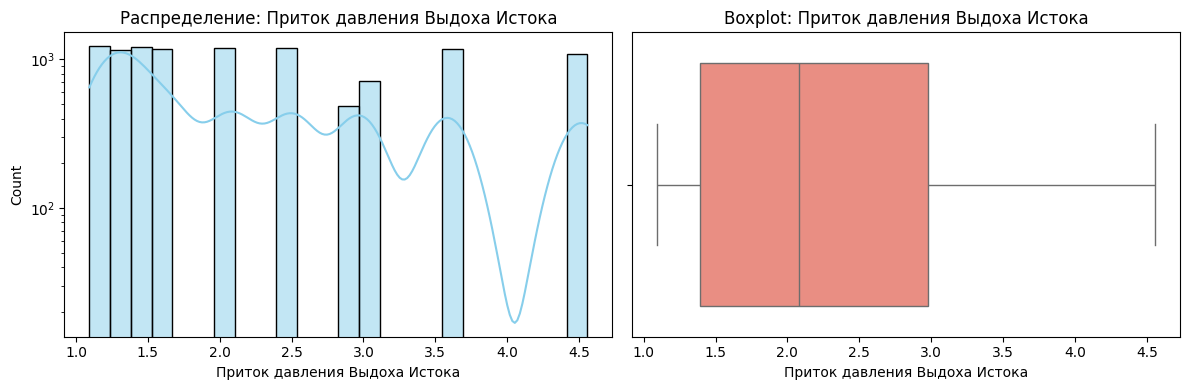

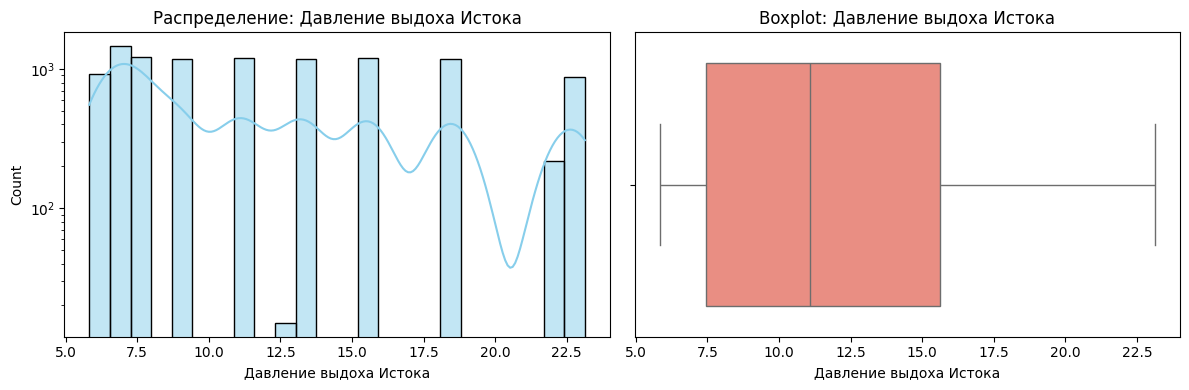

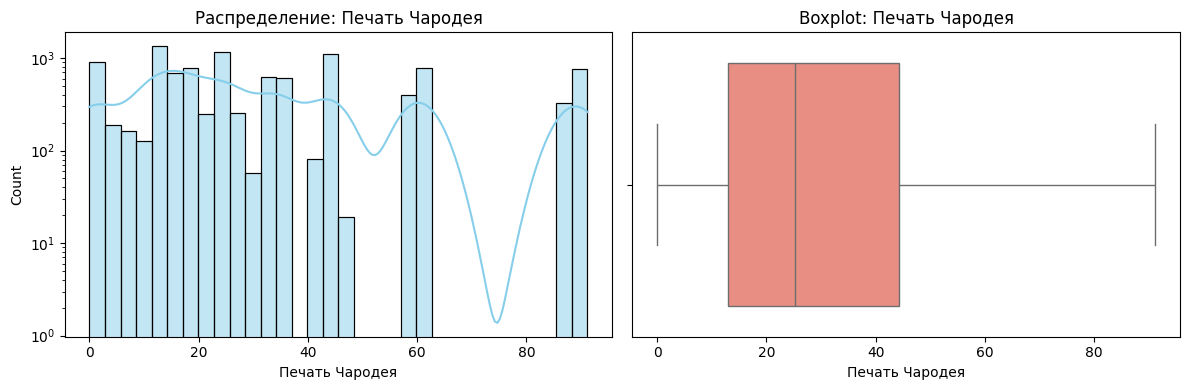

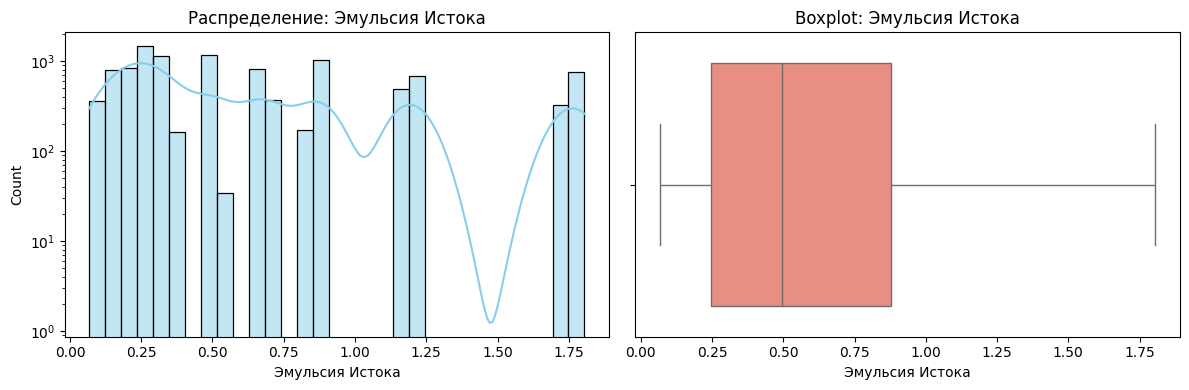

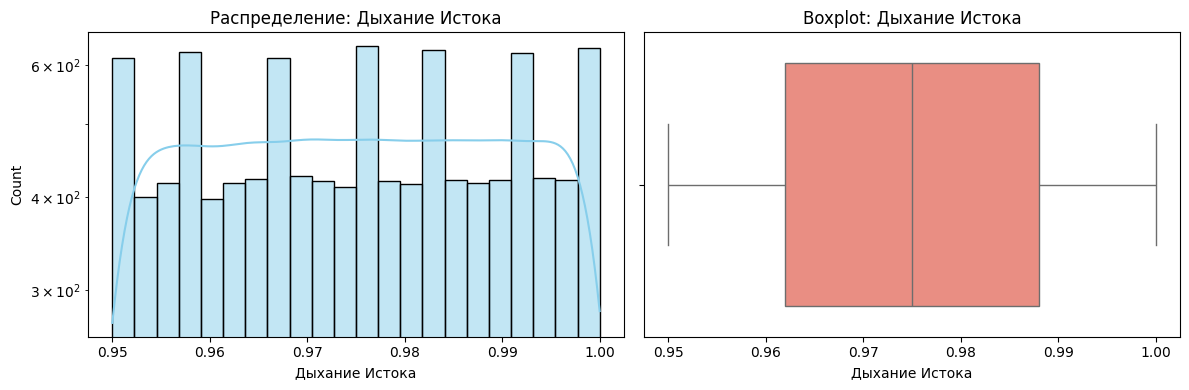

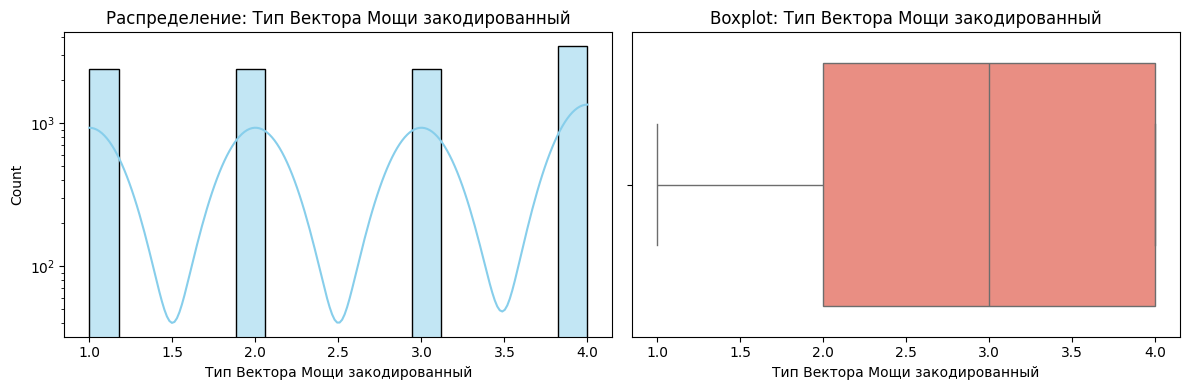

In [60]:
visualize_hist_box(X_train)

Теперь графики выглядят почище, признаки не содержат явных числовых выбросов.

#### 1.1.6.2. <a id='toc1_1_6_2_'></a>[Устранение проблемы наличия аномалий в данных](#toc1_1_6_2_)

Аномальные объекты представляют собой значительные отклонения от основной массы данных. Их присутствие в обучающей выборке часто приводит к переобучению и снижению обобщающей способности модели

##### **Методология фильтрации**:

 - Разнообразие методов: Выбор алгоритмов, анализирующих разные аспекты признакового пространства.

 - Критерий удаления: Объекты исключаются из набора данных только в том случае, если они помечены как аномальные всеми задействованными алгоритмами одновременно.

 - Цель: Снижение влияния шума при сохранении редких, но валидных паттернов.

Для визуализации необходимо понизить пространство до двумерного. Сделаем это при помощи алгоритма UMAP, который способен эффективно сохранять как локальную, так и глобальную структуру данных при снижении размерности.

In [ ]:
from umap import UMAP


X_2d = UMAP(random_state=SEED).fit_transform(X_train)

Для визуализации работа алгоритмов реализуем функцию, которая будет помечать аномальные объекты.

In [62]:
def draw_anomaly(X_2d: np.ndarray[float], anomaly_mask: np.ndarray[bool]) -> None:
    """Визуализация аномальных объектов

    Args:
        X_2d (np.ndarray[float]): Датасет, пониженный до двумерного пространства
        anomaly_mask (np.ndarray[bool]): Маска аномальных объектов
    """
    plt.scatter(X_2d[:, 0], X_2d[:, 1])
    plt.scatter(X_2d[anomaly_mask, 0], X_2d[anomaly_mask, 1], c="red", marker='x')

Также реализуем функцию, которая строит круговую диаграмму с долями аномальных объектов.

In [63]:
def draw_anomaly_pie(anomaly_mask: np.ndarray[bool]) -> None:
    """Визуализация долей аномальных и неаномальных объектов в данных

    Args:
        anomaly_mask (np.ndarray[bool]): Маска аномальных объектов
    """
    _, counts = np.unique(anomaly_mask, return_counts=True)

    plt.pie(counts, labels=counts, autopct='%1.0f%%');
    plt.legend([
        'Нормальные объекты', 'Аномалии'
    ], loc='lower right');

#### 1.1.6.2.1. <a id='toc1_1_6_2_1_'></a>[Поиск на основе IsolationForest](#toc1_1_6_2_1_)

Для выделений аномалий Isolation Forest использует случайные разделения данных, что позволяет быстро и точно идентифицировать выбросы. Алгоритм работает, строя множество случайных деревьев решений и измеряя длину пути, необходимую для изоляции каждой точки данных, где короткие пути указывают на аномалии.

In [ ]:
from pyod.models.iforest import IForest


isf = IForest(random_state=SEED).fit(X_train)
isf_anomaly = isf.predict(X_train)

Данный алгоритм посчитал 1063 объектов аномальными.

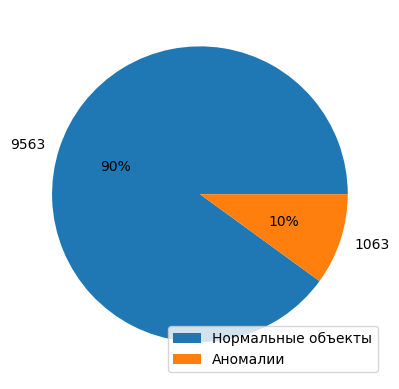

In [65]:
draw_anomaly_pie(isf_anomaly)

Визуализируем в двумерной проекции датасета объекты с выбросами. Видим, что данный алгоритм отметил плотный кластер данных справа на графике, также небольшие кластеры.

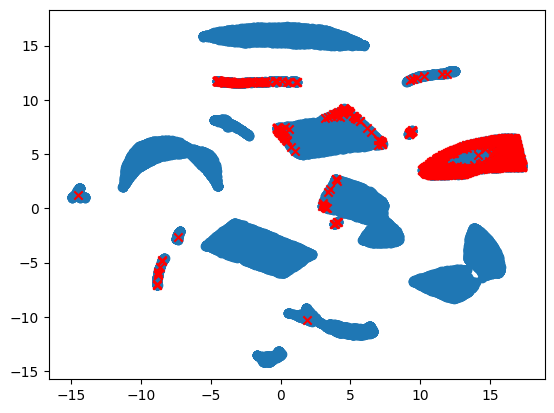

In [66]:
draw_anomaly(X_2d, isf_anomaly.astype(bool))

#### 1.1.6.2.2. <a id='toc1_1_6_2_2_'></a>[Поиск на основе SVM](#toc1_1_6_2_2_)

Алгоритм одноклассового SVM (OCSVM) для поиска аномалий строит гиперплоскость, которая максимально разделяют нормальные данные от аномальных, используя метод опорных векторов для оптимизации границы разделения, исследуя пространственную информацию в признаковом пространстве

In [67]:
from pyod.models.ocsvm import OCSVM


ocsvm = OCSVM().fit(X_train)
ocsvm_anomaly = ocsvm.predict(X_train)

Данный алгоритм, как и предыдущий пометил 1063 точки данных, как аномальные.

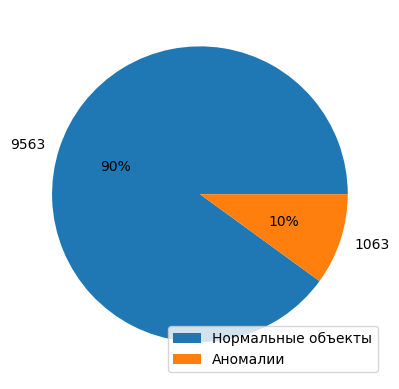

In [68]:
draw_anomaly_pie(ocsvm_anomaly)

Визуализируем в двумерной проекции датасета объекты с выбросами. Видим, что данный алгоритм отметил много маленьких кластеров, также есть и пересечения с предыдущим алгоритмом.

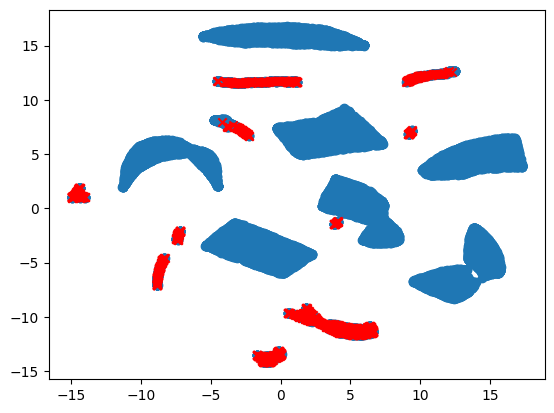

In [69]:
draw_anomaly(X_2d, ocsvm_anomaly.astype(bool))

#### 1.1.6.2.3. <a id='toc1_1_6_2_3_'></a>[Поиск на основе DBSCAN](#toc1_1_6_2_3_)

Алгоритм DBSCAN для поиска аномалий анализирует плотность распределения точек в признаковом пространстве, группируя близко расположенные объекты в кластеры. Он идентифицирует как аномалии те точки, которые находятся в областях с низкой плотностью и не удовлетворяют критериям включения ни в одно из сформированных сообществ, что позволяет эффективно находить изолированные выбросы произвольной формы.

Т.к. DBSCAN очень чувствителен к гиперпараметру eps, проанализируем, какое значение для данного параметра будет оптимальным

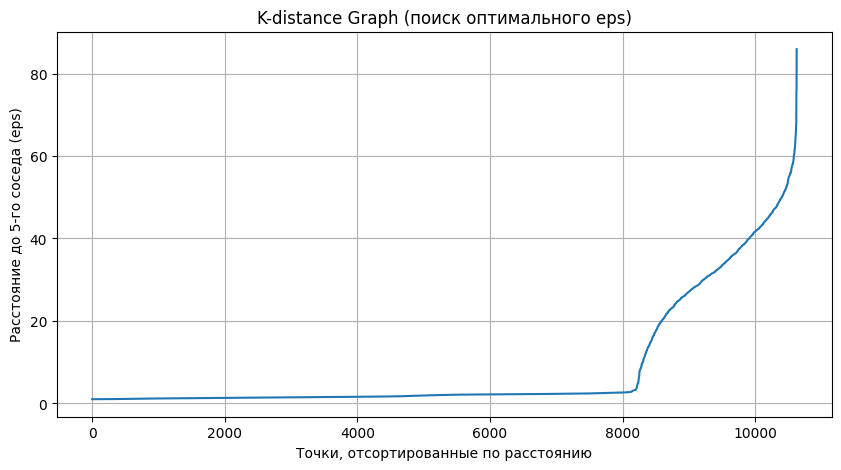

In [70]:
from sklearn.neighbors import NearestNeighbors


neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_train)
distances, indices = neighbors_fit.kneighbors(X_train)

# 2. Сортируем расстояния и строим график
distances = np.sort(distances[:, 4], axis=0)
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph (поиск оптимального eps)')
plt.xlabel('Точки, отсортированные по расстоянию')
plt.ylabel('Расстояние до 5-го соседа (eps)')
plt.grid(True)
plt.show()

Мы видим перелом в районе eps=3, это как раз наша отправная точка, т.к. с этого eps, алгоритм начинает находить значения, которые находятся достаточно далеко, чтобы считать их аномальными, от "ядра" кластера.

Также видим что в диапазоне от 3 до 20 кривая идет довольно плавно, значит что в этом диапазоне алгоритм лучше всего вычисляет, какие из точек явно не относятся к кластеру.

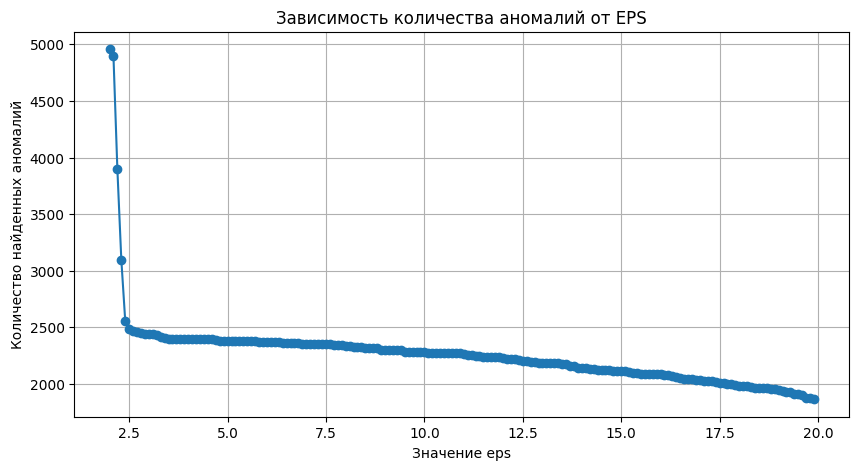

In [71]:
from sklearn.cluster import DBSCAN

eps_values = np.arange(2.0, 20.0, 0.1) # Шаг 0.1 обычно достаточен
anomaly_counts = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5).fit(X_train)
    # Считаем количество аномалий (где метка -1)
    n_anomalies = np.sum(dbscan.labels_ == -1)
    anomaly_counts.append(n_anomalies)

# Строим один график зависимости
plt.figure(figsize=(10, 5))
plt.plot(eps_values, anomaly_counts, marker='o')
plt.title('Зависимость количества аномалий от EPS')
plt.xlabel('Значение eps')
plt.ylabel('Количество найденных аномалий')
plt.grid(True)
plt.show()

Видим, что после в диапазоне от 3 до 7.5 кривая очень плавная, значит что в этом диапазоне точке находятся на "стадии перехода" от 1 кластера к другому, что говорит о аномальности точки. Для реализации возьмем "золотую середину", eps=5.

In [72]:
dbscan = DBSCAN(eps=5, min_samples=5).fit(X_train)
dbscan_anomaly = np.where(dbscan.labels_ == -1, 1, 0)

Для таких гипперпараметров, алгоритм выявил 2381 точку как аномальную, что в 2 раза больше чем предыдущие алгоритмы, но это неудивительно, т.к. dbscan чувствителен к гипперпараметрам. Я постарался подобрать оптимальное значения для параметра eps, ведь если взять eps < 5 - мы будем искать аномалию внутри своего кластера, если eps > 5 мы начнем считать, что некоторые из аномалий на самом деле не аномалии а часть нашего кластера.

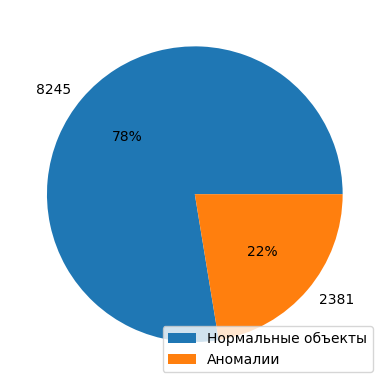

In [73]:
draw_anomaly_pie(dbscan_anomaly)

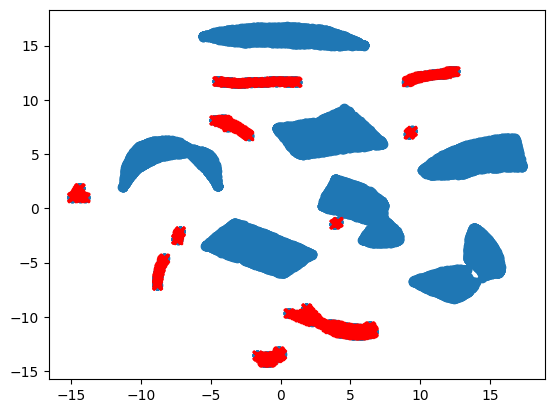

In [74]:
draw_anomaly(X_2d, dbscan_anomaly.astype(bool))

#### 1.1.6.2.4. <a id='toc1_1_6_2_4_'></a>[Удаление аномальных точек](#toc1_1_6_2_4_)

Т.к. каждый из алгоритмов по своему хорош, мы не можем просто взять и начать опираться лишь на один из них, самый разумный способ - взять пересечение всех 3-х алгоритмов => мы точно удалим аномалии, которые будут мешать обучению.

In [75]:
anomalies = np.all(np.array([
    isf_anomaly,
    ocsvm_anomaly,
    dbscan_anomaly,
]), axis=0)
anomalies

array([False, False, False, ..., False, False, False], shape=(10626,))

Визуализируем результат работы трех алгоритмов: 83 объектов были помочены тремя моделями, как аномальные.

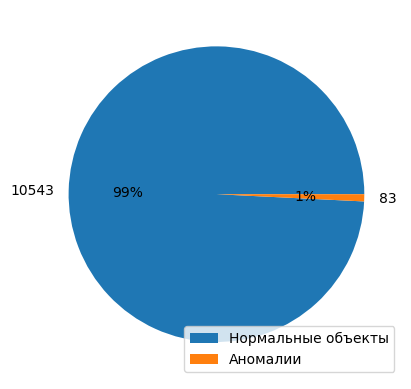

In [76]:
draw_anomaly_pie(anomalies)

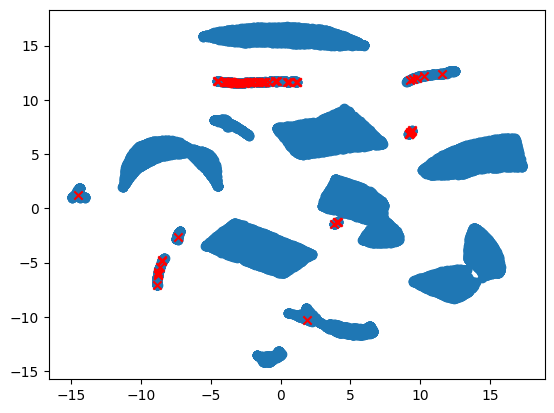

In [77]:
draw_anomaly(X_2d, anomalies)

По двумерной визуализации можно четко увидеть кластер аномальных значений

Вычислим индексы аномальных объектов в исходном датасете, чтобы затем откинуть их.

In [78]:
anomaly_index = X_train.loc[anomalies].index
anomaly_index

Index([ 2106,  3267,  1638,   459,  2151,  3312,  4905,   351,  6876, 10044,
         387,  1053,  8622,   891,  3726,  8604,  9000,  4671,   828,   486,
        7398,  5373,   945,  2142,   936,  9090,   693,   594,  4437,  1575,
        1422, 11619,  2871,  2790,   126,  2835,   873,   360,   666,   630,
        1998,  3069,  2529,  1881,  1539,   900,  4545,  2115,   621,    99,
        3942,   927,  9252,    18,  7191,   396,   153,  2295,   144,  2826,
        6939,   423,  4176,  1125,   855,  2052,  1107,  3591,  1818,   657,
         909,  2367,  3501,   864,   720,   207,   333,  9324,  2592,  2799,
       11151,   180,   108],
      dtype='int64')

In [79]:
X_train = X_train.drop(index=anomaly_index)
y_train = y_train.drop(index=anomaly_index)
X_train.shape

(10543, 14)

### 1.1.7. <a id='toc1_1_7_'></a>[Проблема мультиколлинеарности](#toc1_1_7_)

**Мультиколлинеарность** — это статистическое явление, при котором две или более независимых переменных (признаков) в регрессионной модели сильно коррелируют между собой. Это означает, что одна независимая переменная может быть линейно предсказана из другой с высокой степенью точности. Наличие мультиколлинеарности приводит к неустойчивости коэффициентов модели, увеличению их стандартных ошибок и затрудняет интерпретацию индивидуального вклада каждого признака в предсказание целевой переменной.

#### 1.1.7.1 <a id='toc1_1_7_1_'></a>[Изучение наличия мультиколлинеарности](#toc1_1_7_1_)

#### Корреляционная матрица

Для визуального анализа мультиколлинеарности была построена тепловая карта (heatmap) корреляционной матрицы признаков обучающей выборки. Корреляционная матрица показывает коэффициенты корреляции Пирсона между всеми парами признаков в диапазоне от -1 до 1, где:

- Значения близкие к **1** указывают на сильную положительную линейную связь между признаками
- Значения близкие к **-1** указывают на сильную отрицательную линейную связь
- Значения близкие к **0** указывают на отсутствие линейной связи

Тепловая карта использует цветовое кодирование для наглядного представления силы корреляций: теплые цвета (красный) соответствуют положительным корреляциям, холодные (синий) — отрицательным, а белый цвет — отсутствию корреляции. Высокие значения корреляции между признаками (обычно |r| > 0.8) сигнализируют о потенциальной мультиколлинеарности, что может негативно влиять на качество и интерпретируемость модели.

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

def heatmap_correlation_matrix(X_train: pd.DataFrame) -> None:
    """Визуализация корреляционной матрицы признаков X_train

    Args:
        X_train (pd.DataFrame): Обучающая выборка
    """
    corr = X_train.corr()

    plt.figure(figsize=(max(10, 0.5*X_train.shape[1]), max(8, 0.4*X_train.shape[1])))

    # Визуализация
    sns.heatmap(
        corr, 
        cmap='coolwarm', 
        center=0, 
        annot=True,
        fmt='.2f',
        linewidths=0.5
    )

    plt.title('Корреляционная матрица признаков X_train')
    plt.tight_layout()
    plt.show()

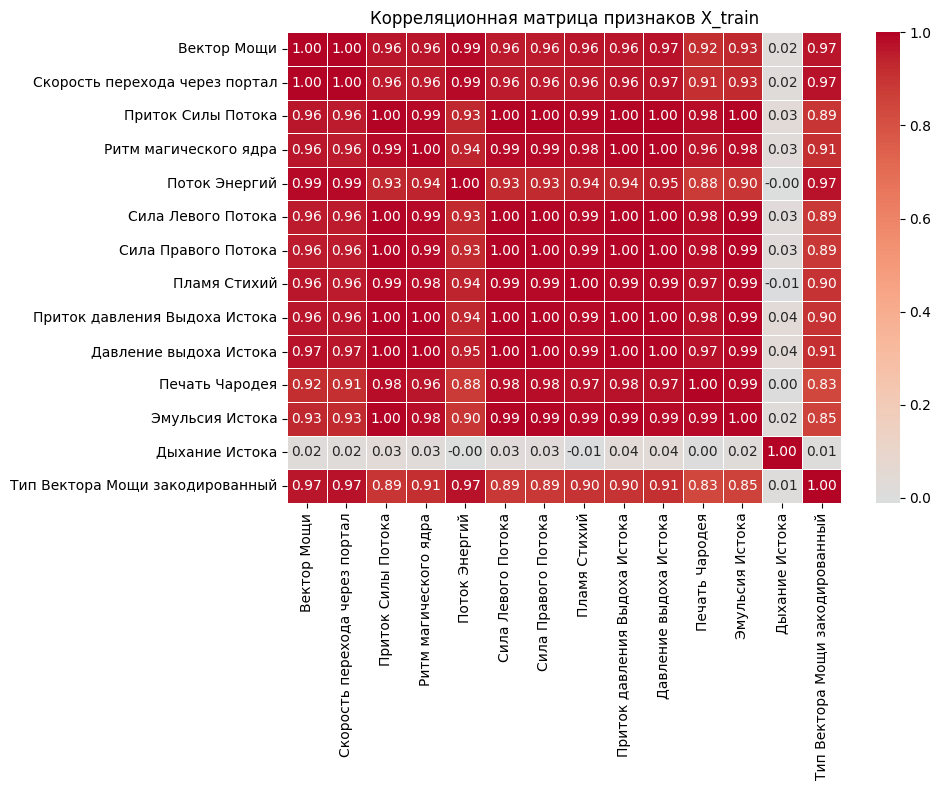

In [81]:
heatmap_correlation_matrix(X_train=X_train)

#### 1.1.7.2 <a id='toc1_1_7_2_'></a>[Устранение проблемы мультиколлинеарности](#toc1_1_7_2_)

Картина, которую мы видим, ужасна. Все признаки имеют высокую мультиколлинеарность, кроме `Дыхание Истока`. В нашей прикладной области мы имеем формулы, которые нам помогут снизить мультиколлинеарность за счет преобразование некоторых признаков в новые. Давайте рассмотрим поподробнее.

1.  **Общая мощность потоков** = `Сила Левого Потока` + `Сила Правого Потока`
2.  **Суммарная сила всех потоков** = `Сила Левого Потока` + `Сила Правого Потока` + `Приток Силы Потока`
3.  **Общая сила ядра** = `Ритм магического ядра` * `Приток Силы Потока`
4.  **Общее давление на выходе** = `Приток давления Выдоха Истока` + `Давление выдоха Истока`
5.  **Магическая производительность** = `Скорость перехода через портал` / `Эмульсия Истока`
6.  **Эффективность ядра** = `Общая сила ядра` / `Эмульсия Истока`

In [82]:
# # Переменная, которая будет в себе содержать те признаки, которые не будут участвовать в прогнозировании
feature_exclusion = []

`Сила Левого Потока`, `Сила Правого Потока` и `Приток Силы Потока` имеют попарную корреляцию равную 1, это указывает на идентичность признаков. Их можно было бы преобразовать в новый **Суммарная сила всех потоков** = `Сила Левого Потока` + `Сила Правого Потока` + `Приток Силы Потока`, однако мы также имеем формулу: **Общая сила ядра** = `Ритм магического ядра` * `Приток Силы Потока`, которая также содержит признак `Приток Силы Потока`. Чтобы новые признаки не содержали информацию на основе одного и того же признака, использую следующую формулу для введения нового признака **Общая мощность потоков** = `Сила Левого Потока` + `Сила Правого Потока`

In [83]:
X_train['Общая мощность потоков'] = X_train['Сила Левого Потока'] + X_train['Сила Правого Потока']
X_test['Общая мощность потоков'] = X_test['Сила Левого Потока'] + X_test['Сила Правого Потока']
feature_exclusion.extend(['Сила Левого Потока', 'Сила Правого Потока'])
X_train['Общая мощность потоков']

5388      664.760
5166       12.448
11024    1289.436
2644      876.260
4203       14.090
           ...   
4794      664.342
239       492.442
7196      492.354
1388      120.760
2957      492.530
Name: Общая мощность потоков, Length: 10543, dtype: float64

Как и сказал выше, существует формула: **Общая сила ядра** = `Ритм магического ядра` * `Приток Силы Потока`, где `Ритм магического ядра` и `Приток Силы Потока` имеют корреляцию 0.99, тогда в соответствии с формулой введем новый признак `Общая сила ядра`

In [84]:
X_train['Общая Сила Ядра'] = X_train['Ритм магического ядра'] * X_train['Приток Силы Потока']
X_test['Общая Сила Ядра'] = X_test['Ритм магического ядра'] * X_test['Приток Силы Потока']
feature_exclusion.extend(['Ритм магического ядра', 'Приток Силы Потока'])
X_train['Общая Сила Ядра']

5388     1.093652e+07
5166     4.256284e+05
11024    2.712623e+07
2644     1.648895e+07
4203     4.967055e+04
             ...     
4794     1.093440e+07
239      7.198804e+06
7196     7.198403e+06
1388     1.217111e+06
2957     7.198918e+06
Name: Общая Сила Ядра, Length: 10543, dtype: float64

Признаки "Приток давления Выдоха Истока" и "Давление выдоха Истока" имеют корреляцию равную 1, введу новый признак **Общее давление на выходе** = `Приток давления Выдоха Истока` + `Давление выдоха Истока`.

In [85]:
X_train['Общее давление на выходе'] = X_train['Давление выдоха Истока'] + X_train['Приток давления Выдоха Истока']
X_test['Общее давление на выходе'] = X_test['Давление выдоха Истока'] + X_test['Приток давления Выдоха Истока']
feature_exclusion.extend(['Давление выдоха Истока', 'Приток давления Выдоха Истока'])
X_train['Общее давление на выходе']

5388     18.734
5166      7.727
11024    27.618
2644     22.098
4203      6.926
          ...  
4794     18.509
239      15.860
7196     15.661
1388      8.790
2957     15.661
Name: Общее давление на выходе, Length: 10543, dtype: float64

Признаки "Скорость перехода через портал" и "Эмульсия Истока" имеют корреляцию равную 0.93, введу новую переменную: **Магическая производительность** = `Скорость перехода через портал` / `Эмульсия Истока`

In [86]:
X_train['Магическая производительность'] = X_train['Скорость перехода через портал'] / X_train['Эмульсия Истока']
X_test['Магическая производительность'] = X_test['Скорость перехода через портал'] / X_test['Эмульсия Истока']
feature_exclusion.extend(['Скорость перехода через портал', 'Эмульсия Истока'])
X_train['Магическая производительность']

5388     12.076398
5166      7.349143
11024     7.909954
2644     10.170148
4203     21.394017
           ...    
4794     12.346560
239      13.097482
7196     13.903784
1388     19.211452
2957     13.637585
Name: Магическая производительность, Length: 10543, dtype: float64

Т.к. у нас существует формула: **Эффективность ядра** = `Общая сила ядра` / `Эмульсия Истока`, проверим как эти два признака коррелируют друг с другом, если значение высокое введем новый признак `Эффективность ядра`. А если быть точнее, т.к. `Эмульсия Истока` была ранее использована и занесена с список для удаления, проверим корреляцию между `Общая сила ядра` и `Магическая производительность`

In [87]:
corr_2 = X_train[['Общая Сила Ядра', 'Магическая производительность']].corr()
corr_2

,Общая Сила Ядра,Магическая производительность
Общая Сила Ядра,1.000000,-0.651945
Магическая производительность,-0.651945,1.000000


Видим, что показатель корреляции средний (~ -0.65), учитывая нашу базовые значения, это хороший показатель, однако признак `Эффективность ядра` стоит ввести, т.к. признак `Общая сила ядра` был получен при помощи перемножения двух признаков, что может создать проблему наличия выбросов. 

Чтобы не произошло ситуации деление на 0, сначала проверим содержать ли наши выборки `Эмульсия ядра` == 0, если какие-то строки содержат 0, прибавим к ним небольшое значение равное $10^{-9}$

In [88]:
zeros_train = (X_train['Эмульсия Истока'] == 0).sum()
zeros_test = (X_test['Эмульсия Истока'] == 0).sum()

print(f"Нулей в X_train: {zeros_train}, в X_test: {zeros_test}")

Нулей в X_train: 0, в X_test: 0


Видим, что этот признак не содержит нулей, значит смело вводим новый признак

In [89]:
X_train['Эффективность Ядра'] = X_train['Общая Сила Ядра'] / X_train['Эмульсия Истока']
X_test['Эффективность Ядра'] = X_test['Общая Сила Ядра'] / X_test['Эмульсия Истока']
feature_exclusion.extend(['Общая Сила Ядра'])
X_train['Эффективность Ядра']

5388     1.226067e+07
5166     2.026802e+06
11024    1.544774e+07
2644     1.358233e+07
4203     6.712236e+05
             ...     
4794     1.249645e+07
239      1.018218e+07
7196     1.080841e+07
1388     5.050254e+06
2957     1.060224e+07
Name: Эффективность Ядра, Length: 10543, dtype: float64

Т.к. теперь два признака `Эффективность ядра` и `Магическая производительность` содержат информацию о признаке `Эмульсия Истока`, стоит проверить их корреляцию

In [90]:
corr4 = X_train[['Эффективность Ядра', 'Магическая производительность']].corr()
corr4

,Эффективность Ядра,Магическая производительность
Эффективность Ядра,1.000000,-0.513874
Магическая производительность,-0.513874,1.000000


Видим, что показатель корреляции ~ -0.51 и это наша победа, независимо от того, что оба признака содержать информацию об одном и том же признаке, они описываю разные магические процессы.

Давайте посмотрим какие признаки будут удалены из наших выборок и не будут участвовать при обучении

In [91]:
feature_exclusion

['Сила Левого Потока',
 'Сила Правого Потока',
 'Ритм магического ядра',
 'Приток Силы Потока',
 'Давление выдоха Истока',
 'Приток давления Выдоха Истока',
 'Скорость перехода через портал',
 'Эмульсия Истока',
 'Общая Сила Ядра']

In [99]:
X_train = X_train.drop(columns=feature_exclusion)
X_test = X_test.drop(columns=feature_exclusion)

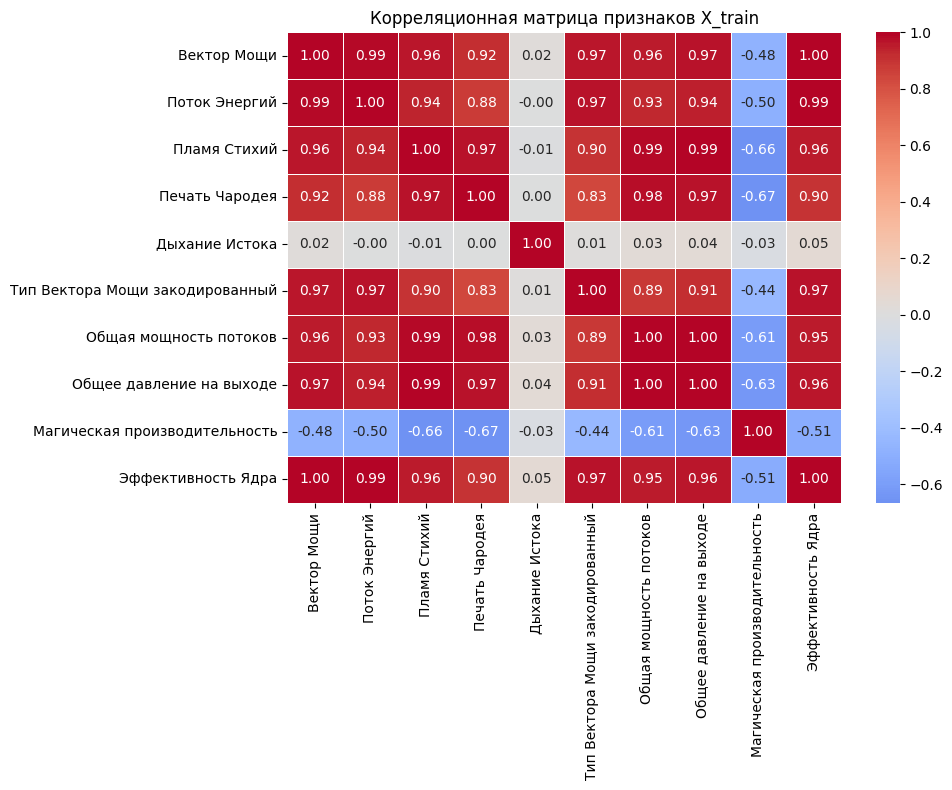

In [100]:
heatmap_correlation_matrix(X_train=X_train)

#### Выводы по анализу мультиколлинеарности

На основе анализа корреляционной матрицы была выявлена значительная мультиколлинеарность между признаками исходной обучающей выборки. Большинство признаков демонстрировали очень высокие коэффициенты корреляции (0.96-1.00), что указывало на избыточность информации и потенциальные проблемы при построении регрессионных моделей.

Для устранения мультиколлинеарности был применён подход feature engineering с использованием знаний из прикладной области. Исходные 14 признаков были преобразованы и агрегированы в 10 новых признаков, которые более точно отражают физическую суть процессов и содержат меньше избыточной информации.

После преобразования признаков:
- Количество признаков сократилось с 14 до 10
- Максимальные значения корреляций снизились, хотя некоторые высокие корреляции (0.96-0.99) всё ещё присутствуют
- Появились признаки с отрицательной корреляцией, что добавляет разнообразие во взаимосвязи признаков
- Новые признаки обладают лучшей интерпретируемостью через агрегацию физических величин (общая мощность, общее давление)

#### Рекомендации по выбору моделей

Несмотря на проведённую работу по снижению мультиколлинеарности, в данных всё ещё присутствуют высококоррелированные признаки. В связи с этим:

**Для линейных моделей** рекомендуется использовать регуляризацию:
- **Ridge регрессия** — наиболее устойчива к мультиколлинеарности за счёт L2-регуляризации, которая штрафует большие коэффициенты
- **Lasso регрессия** — может автоматически отбирать наиболее значимые признаки через L1-регуляризацию
- **LinearRegression** без регуляризации будет использована как baseline для оценки влияния мультиколлинеарности на качество модели

**Древовидные модели** являются предпочтительными в данной ситуации:
- **Деревья решений** и **случайный лес (Random Forest)** — естественным образом устойчивы к мультиколлинеарности, так как на каждом разбиении выбирается только один признак
- **Градиентный бустинг** (XGBoost, LightGBM, CatBoost) — также демонстрируют высокую устойчивость к коррелированным признакам и способны эффективно работать с избыточной информацией

Для подтверждения выводов в качестве baseline-моделей будут использованы LinearRegression (для демонстрации проблем мультиколлинеарности) и Ridge (как устойчивая альтернатива с регуляризацией).

In [101]:
X_train.describe()

,Вектор Мощи,Поток Энергий,Пламя Стихий,Печать Чародея,Дыхание Истока,Тип Вектора Мощи закодированный,Общая мощность потоков,Общее давление на выходе,Магическая производительность,Эффективность Ядра
count,10543.000000,10543.000000,10543.000000,10543.000000,10543.000000,10543.000000,10543.000000,10543.000000,10543.000000,1.054300e+04
mean,5.153113,8195.675487,733.299128,33.187739,0.975239,2.665465,449.406569,14.573535,13.891376,8.765612e+06
std,2.593651,1081.853328,170.024469,25.349228,0.014659,1.147659,394.228194,6.326121,4.216542,4.357115e+06
min,1.138000,6589.002000,444.731000,0.000000,0.950000,1.000000,10.636000,6.924000,4.555042,4.373923e+05
25%,3.144000,7061.777000,590.157500,13.181500,0.963000,2.000000,120.640000,8.842000,10.446602,4.926634e+06
50%,5.140000,8481.264000,705.817000,25.246000,0.975000,3.000000,350.532000,13.171000,13.657699,8.771238e+06
75%,7.148000,9131.332500,831.589500,44.399500,0.988000,4.000000,664.693000,18.608000,17.945581,1.268317e+07
max,9.300000,9797.103000,1103.030000,91.179000,1.000000,4.000000,1290.498000,27.691000,25.094634,1.592358e+07
